In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
from pathlib import Path
sys.path.append('/lab/barcheese01/smaffa/coTISja/src')

from scripts.plotting import *
from scripts.filter_utils import *
import re

pd.set_option('display.max_columns', None)

In [11]:
# from raw sample-level data
sample_level_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/combined/all_samples_filtered_with_protein_seq.csv')
sample_level_tis_df = calculate_normalization_factors(sample_level_tis_df, pseudocount=1)

# grab normalization factors
experiment_table, sample_df, replicate_df = load_experiment_manifest()
tisdiff_manifest = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/ribotish_tisdiff_manifest.tsv', sep='\t')
samples = experiment_table['sample'].tolist()
codon_order = ['ATG', 'ATA', 'ATC', 'ATT', 'ACG', 'AAG', 'AGG', 'GTG', 'TTG', 'CTG']
sample_to_riboseq_total = replicate_df[replicate_df['condition'] == 'TIS'].groupby('sample')['bam_qc_file'].apply(list).apply(lambda x: np.sum([calculate_read_totals_from_bam_qc(y) for y in x]))
sample_to_riboseq_scale_factor = (sample_to_riboseq_total.median() / sample_to_riboseq_total).rename('SampleRPFScaleFactor')
sample_level_tis_df = sample_level_tis_df.merge(sample_to_riboseq_scale_factor, left_on='Sample', right_index=True)

sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

# from DESeq2 transformation
vst_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/translation_efficiency_vst_matrix.csv', index_col=0)
deseq_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/log_translation_efficiency_coeffs.csv', index_col=0)
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
# riboseq_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts_masked.csv', index_col=0)
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5
# rna_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts_masked.csv', index_col=0)

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log

In [5]:
replicate_level_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/per_rep/all_samples_filtered_with_protein_seq.csv')
replicate_level_tis_df = replicate_level_tis_df.assign(
    TIS=replicate_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)
tis_metadata = replicate_level_tis_df[['TIS', 'Tid', 'Symbol', 'Gid', 'GeneType', 'StartCodon', 'Start', 'RecatTISType', 'MANE_Select', 'AALen', 'AASeq']].drop_duplicates()

<Axes: xlabel='LogTranslationEfficiency', ylabel='Density'>

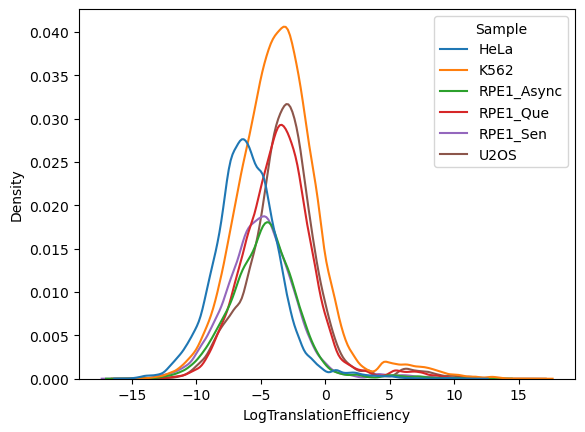

In [ ]:
# calculate TE values
sample_level_tis_df = sample_level_tis_df.assign(
    LogTranslationEfficiency = lambda x: np.log2(x['SampleRPFScaleFactor'] * (x['TISCounts'] + 1)) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    # LogTranslationEfficiency = lambda x: np.log2(x['TISCounts'] + 1) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    TranslationEfficiency = lambda x: 2**x['LogTranslationEfficiency']
)

sns.kdeplot(
    sample_level_tis_df,
    x='LogTranslationEfficiency', hue='Sample'
)

<Axes: xlabel='LogTranslationEfficiency', ylabel='Density'>

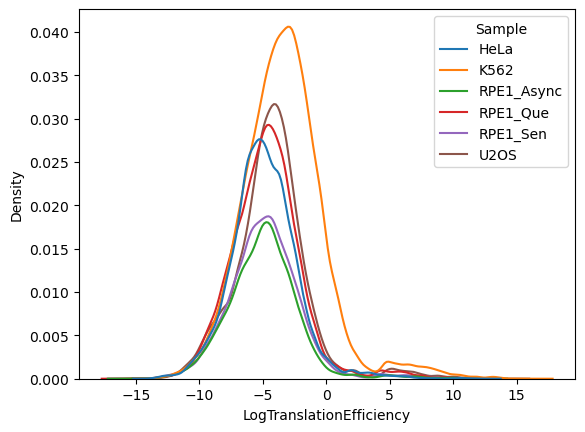

In [6]:
# calculate TE values
sample_level_tis_df = sample_level_tis_df.assign(
    # LogTranslationEfficiency = lambda x: np.log2(x['SampleRPFScaleFactor'] * (x['TISCounts'] + 1)) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    LogTranslationEfficiency = lambda x: np.log2(x['TISCounts'] + 1) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    TranslationEfficiency = lambda x: 2**x['LogTranslationEfficiency']
)
sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

sns.kdeplot(
    sample_level_tis_df,
    x='LogTranslationEfficiency', hue='Sample'
)

<Axes: xlabel='value', ylabel='Density'>

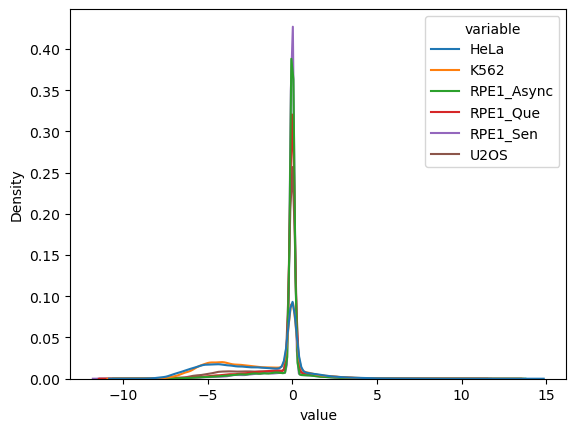

In [17]:
sns.kdeplot(
    vst_log_te_matrix.melt(),
    x='value', hue='variable'
)

<Axes: xlabel='value', ylabel='Density'>

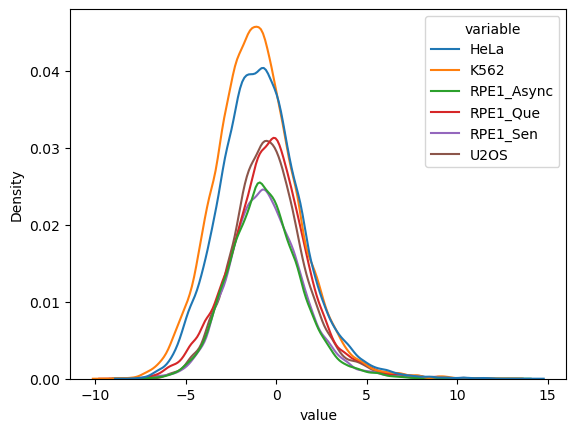

In [8]:
sns.kdeplot(
    vst_log_te_matrix[tis_mask].melt(),
    x='value', hue='variable'
)

<Axes: xlabel='value', ylabel='Density'>

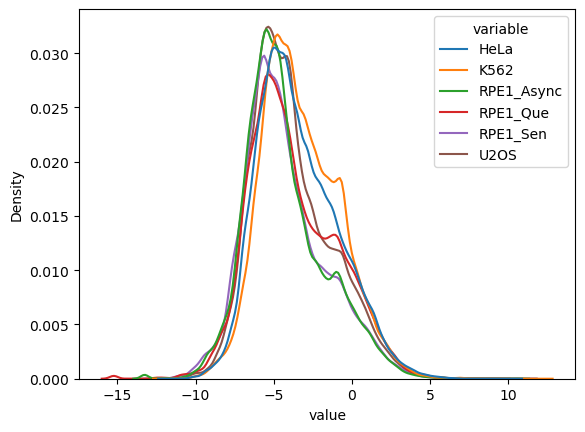

In [9]:
sns.kdeplot(
    vst_log_te_matrix[rna_mask].melt(),
    x='value', hue='variable'
)

<Axes: xlabel='value', ylabel='Density'>

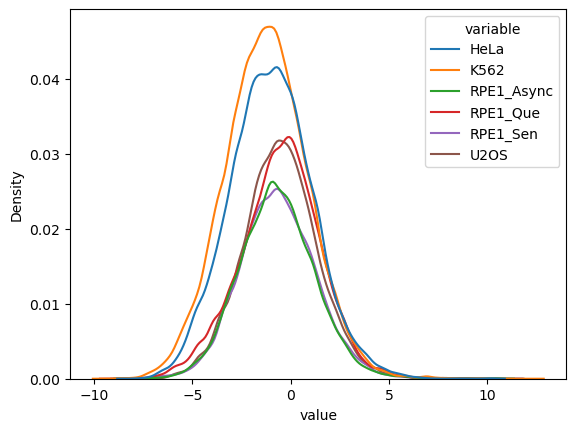

In [10]:
sns.kdeplot(
    vst_log_te_matrix[tis_mask & rna_mask].melt(),
    x='value', hue='variable'
)

Text(0, 0.5, 'Log TE with Variance-Stabilizing Transform (VST) ')

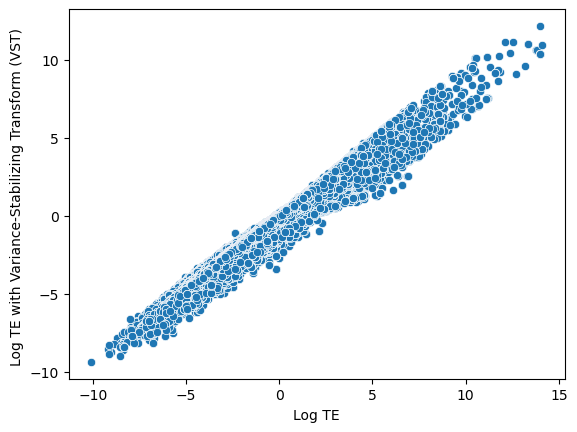

In [12]:
sns.scatterplot(
    vst_log_te_matrix[tis_mask & rna_mask].melt(ignore_index=False, value_name='vst').reset_index().merge(
        deseq_log_te_matrix[tis_mask & rna_mask].melt(ignore_index=False, value_name='non_vst').reset_index()
    ),
    x='non_vst', y='vst',
)
plt.xlabel('Log TE')
plt.ylabel('Log TE with Variance-Stabilizing Transform (VST) ')

In [13]:
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

Text(0, 0.5, 'Number of TISs')

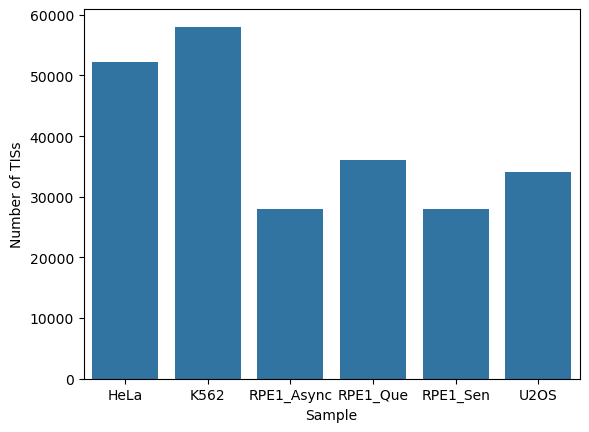

In [14]:
sns.barplot((~(masked_te_matrix.isna())).sum().rename('N_TIS').reset_index().rename({'index': 'Sample'}, axis=1), x='Sample', y='N_TIS')
plt.ylabel('Number of TISs')

# Summarizing differential TIS metrics

1) Need to find a way to summarize per TIS, or make a function to extract when queried, the matrix of differential comparisons between samples
    - Done: exported stacked matrices per TIS over all pairs of samples
2) Want to find a way to summarize per TIS, the "outlier-ness" of translation efficiency values in any cell line, along with a statistical measure of this quantity - maybe these are worth experimentally testing
    - Ranking heuristic is ok: reporting the variance, maximum, and minimum of TE values, along with the most significant and median differential qvalue per TIS. Outliers should have high variance and a most significant q-value which is far from the median q-value. Conversely, non-outliers but differential across samples should have high variance, and a significant median q-value (i.e. more than half of pairwise comparisons should have significant differences in translation efficiency)
3) Want to report some statistical measure per TIS, of "interesting-ness" / "different-ness" across cell lines
    - TODO: some rank which combines these?
    - ranks for each (outlier-ness, vs. differential across all pairs)?
4) Need to make some gene-level comparisons with RNA expression or protein expression or essentiality across cell lines
    - TODO: use the highest ranking "differential across all pairs" or highest variance TISs as a subset of genes to run correlations with other measurements?
    - TODO: GO enrichment analysis on the genes with the most differential TISs?
5) Add functional annotations:
    - TODO: DeepLoc2.0
    - SLiM enrichment within the differential domains
    - TODO: Presence of peptide in mass spec data

In [15]:
pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pairwise_wald/{f}', index_col=0)

In [16]:
# function to pull out statistics for a TIS across all pairwise comparisons
def extract_TIS_matrix(TIS, pairwise_dict=pairwise_wald_tests, comparison_metric='log2FoldChange', masked_tis_matrix=masked_te_matrix):
    single_samples = set()
    for s1, s2 in pairwise_dict:
        single_samples.add(s1)
        single_samples.add(s2)
    single_samples = sorted(list(single_samples))
    n_samples = len(single_samples)

    output_matrix = np.empty(shape=(n_samples, n_samples))
    output_matrix.fill(np.nan)
    output_matrix = pd.DataFrame(output_matrix, index=single_samples, columns=single_samples)

    for pair, df in pairwise_dict.items():
        s1, s2 = pair
        if TIS in df.index.tolist():
            output_matrix.loc[s1, s2] = df.loc[TIS, comparison_metric]
        if masked_tis_matrix is not None:
            if TIS in masked_tis_matrix.index.tolist() and s1 in masked_tis_matrix.columns.tolist() and s2 in masked_tis_matrix.columns.tolist():
                if np.isnan(masked_tis_matrix.loc[TIS, s1]) and np.isnan(masked_tis_matrix.loc[TIS, s2]):
                    output_matrix.loc[s1, s2] = np.nan

    return output_matrix

In [17]:
def extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=pairwise_wald_tests, masked_tis_matrix=masked_te_matrix):
    single_samples = set()
    tis_superindex = set()
    for s1, s2 in pairwise_dict:
        single_samples.add(s1)
        single_samples.add(s2)
        tis_superindex = tis_superindex.union(pairwise_dict[(s1, s2)].index.tolist())
    single_samples = sorted(list(single_samples))
    tis_superindex = sorted(list(tis_superindex))
    n_samples = len(single_samples)
    n_tis = len(tis_superindex)

    sample_index = pd.Series(range(n_samples), index=single_samples)
    tis_index = pd.Series(range(n_tis), index=tis_superindex)

    output_matrix = np.empty(shape=(n_tis, n_samples, n_samples))
    output_matrix.fill(np.nan)

    for pair, df in tqdm(pairwise_dict.items()):
        s1, s2 = pair
        output_matrix[:, sample_index.loc[s1], sample_index.loc[s2]] = df.reindex(index=tis_superindex)[comparison_metric].values

        if masked_tis_matrix is not None:
            na_mask = masked_tis_matrix.reindex(index=tis_superindex)[[s1, s2]].isna().all(axis=1).tolist()
            output_matrix[na_mask, sample_index.loc[s1], sample_index.loc[s2]] = np.nan

    output_block = pd.DataFrame(
        output_matrix.reshape(tis_index.shape[0] * sample_index.shape[0], sample_index.shape[0]),
        index=pd.MultiIndex.from_product([tis_index.index.tolist(), sample_index.index.tolist()], names=['TIS', 'TestSample']),
        columns=sample_index.index.tolist()
    )
    output_block.columns.name='RefSample'
    return output_block

In [18]:
lfc_block = extract_TIS_block(comparison_metric='log2FoldChange')
pval_block = extract_TIS_block(comparison_metric='pvalue')
qval_block = extract_TIS_block(comparison_metric='padj')

100%|██████████| 15/15 [00:03<00:00,  4.69it/s]


In [19]:
lfc_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/lfc_matrix_stack.csv')
pval_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pval_matrix_stack.csv')
qval_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/qval_matrix_stack.csv')

In [20]:
lfc_block = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/lfc_matrix_stack.csv', index_col=[0, 1])
lfc_block.columns.name = 'RefSample'
pval_block = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pval_matrix_stack.csv', index_col=[0, 1])
pval_block.columns.name = 'RefSample'
qval_block = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/qval_matrix_stack.csv', index_col=[0, 1])
qval_block.columns.name = 'RefSample'

In [31]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+', masked_tis_matrix=None)

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,-2.320435,NaN,NaN,NaN,NaN,NaN
RPE1_Async,-2.305267,0.015168,NaN,NaN,NaN,NaN
RPE1_Que,-2.827418,-0.506983,-0.522151,NaN,NaN,NaN
RPE1_Sen,-2.225019,0.095415,0.080248,0.602398,NaN,NaN
U2OS,-0.783553,1.536882,1.521714,2.043865,1.441467,NaN


In [ ]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+', masked_tis_matrix=None, comparison_metric='padj')

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,0.006688,NaN,NaN,NaN,NaN,NaN
RPE1_Async,0.276164,1.000000,NaN,NaN,NaN,NaN
RPE1_Que,0.165688,0.940888,1.0,NaN,NaN,NaN
RPE1_Sen,0.130065,1.000000,1.0,1.000000,NaN,NaN
U2OS,0.454491,0.244651,1.0,0.882203,1.0,NaN


In [ ]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+')

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,-2.320435,NaN,NaN,NaN,NaN,NaN
RPE1_Async,-2.305267,0.015168,NaN,NaN,NaN,NaN
RPE1_Que,-2.827418,-0.506983,NaN,NaN,NaN,NaN
RPE1_Sen,-2.225019,0.095415,NaN,NaN,NaN,NaN
U2OS,-0.783553,1.536882,1.521714,2.043865,1.441467,NaN


In [120]:
def calculate_variance_shifts(matrix, baseline_variance=None):
    """
    Calculates the changes in variance across the rows after removing each column
    """
    if baseline_variance is None:
        baseline_variance = matrix.var(axis=1)
    column_dropped_to_remaining_variance = dict()
    for c in matrix.columns:
        column_dropped_to_remaining_variance[c] = matrix.drop([c], axis=1).var(axis=1).rename(c)
    dropped_variances = pd.concat(column_dropped_to_remaining_variance, axis=1)

    variance_shifts = (dropped_variances.T - baseline_variance).T
    variance_shifts[~(matrix.isna()) & dropped_variances.isna()] = -np.inf
    return variance_shifts, dropped_variances

def calculate_range_shifts(matrix):
    """
    Calculates the changes in range across the rows after removing each column
    """
    baseline_range = matrix.max(axis=1) - matrix.min(axis=1)
    column_dropped_to_remaining_range = dict()
    for c in matrix.columns:
        dropped_matrix = matrix.drop([c], axis=1)
        column_dropped_to_remaining_range[c] = (dropped_matrix.max(axis=1) - dropped_matrix.min(axis=1)).rename(c)
    dropped_ranges = pd.concat(column_dropped_to_remaining_range, axis=1)

    range_shifts = (dropped_ranges.T - baseline_range).T
    return range_shifts, dropped_ranges

In [99]:
# measure of uniqueness across cell lines
# 1) how many cell lines is the TIS detected in?
# 2) what is the variance in the translation efficiency across cell lines?
#   a) ranks are maybe only consistent within groups by number of cell lines
n_samples_per_tis = (~masked_te_matrix.isna()).sum(axis=1).rename('NSamples')
variance_per_tis = masked_te_matrix.var(axis=1).rename('LogTEVariance')

variance_shifts, dropped_variances = calculate_variance_shifts(masked_te_matrix, baseline_variance=variance_per_tis)
min_delta_variance = variance_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaVariance')
range_shifts, dropped_ranges = calculate_range_shifts(masked_te_matrix)
min_delta_range = range_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaRange')
min_delta_variance_sample = variance_shifts.idxmin(axis=1).rename('CandidateOutlier')

min_te_per_tis = masked_te_matrix.min(axis=1).rename('MinLogRiboOverRNA')
min_te_sample_per_tis = masked_te_matrix.dropna(how='all').idxmin(axis=1).rename('MinLogTESample')
max_te_per_tis = masked_te_matrix.max(axis=1).rename('MaxLogRiboOverRNA')
max_te_sample_per_tis = masked_te_matrix.dropna(how='all').idxmax(axis=1).rename('MaxLogTESample')

lfc_reshaped = lfc_block.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
qval_reshaped = qval_block.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
min_lfc_per_tis = lfc_reshaped.min(axis=1).rename('MinLFC')
min_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinLFCSamplePair')
max_lfc_per_tis = lfc_reshaped.max(axis=1).rename('MaxLFCSamplePair')
max_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmax(axis=1).apply(lambda x: '/'.join(x)).rename('MaxLFCSamplePair')
min_diffq_per_tis = qval_reshaped.min(axis=1).rename('MinDiffQVal')
min_diffq_pair_per_tis = qval_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinDiffQValSamplePair')
median_diffq_per_tis = qval_reshaped.median(axis=1).rename('MedianDiffQVal')
max_diffq_per_tis = qval_reshaped.max(axis=1).rename('MaxDiffQVal')
min_median_diffq_magnitude_diff_per_tis = (np.log10(min_diffq_per_tis) - np.log10(median_diffq_per_tis)).abs().rename('QValMinMedianMagnitudeDiff')

In [23]:
directions = []
for tis, min_idx in tqdm(qval_reshaped.dropna(how='all').idxmin(axis=1).items()):
    directions.append(np.sign(lfc_reshaped.loc[tis, min_idx]))
most_sig_direction_per_tis = pd.Series(directions, index=qval_reshaped.dropna(how='all').index).rename('MinDiffQValDirection')

92820it [00:13, 6822.75it/s]


In [24]:
max_riboseq_counts_per_tis = riboseq_counts.max(axis=1).rename('MaxRiboseqCounts')
max_riboseq_rpm_per_tis = ((riboseq_counts / sample_to_riboseq_total) * 1e6).max(axis=1).rename('MaxRiboseqRPM')
max_riboseq_sample_per_tis = ((riboseq_counts / sample_to_riboseq_total) * 1e6).idxmax(axis=1).rename('MaxRiboseqSample')
min_riboseq_counts_per_tis = riboseq_counts.min(axis=1).rename('MinRiboseqCounts')
min_riboseq_rpm_per_tis = ((riboseq_counts / sample_to_riboseq_total) * 1e6).min(axis=1).rename('MinRiboseqRPM')
min_riboseq_sample_per_tis = ((riboseq_counts / sample_to_riboseq_total) * 1e6).idxmin(axis=1).rename('MinRiboseqSample')

In [63]:
tis_stats = pd.concat([
    n_samples_per_tis, variance_per_tis,
    max_riboseq_counts_per_tis, max_riboseq_rpm_per_tis, max_riboseq_sample_per_tis, min_riboseq_counts_per_tis, min_riboseq_rpm_per_tis, min_riboseq_sample_per_tis,
    max_te_per_tis, max_te_sample_per_tis, min_te_per_tis, min_te_sample_per_tis,
    max_lfc_per_tis, max_lfc_pair_per_tis, min_lfc_per_tis, min_lfc_pair_per_tis, most_sig_direction_per_tis,
    min_diffq_per_tis, min_diffq_pair_per_tis, median_diffq_per_tis, max_diffq_per_tis, min_median_diffq_magnitude_diff_per_tis,
    min_delta_variance, min_delta_range, min_delta_variance_sample
], axis=1)
tis_summary = tis_metadata.merge(tis_stats, left_on='TIS', right_index=True)
tis_summary = tis_summary.dropna(subset=['NSamples'])

In [105]:
def summarize_tis_stats_across_samples(
    te_matrix=masked_te_matrix, 
    lfc_stack=lfc_block, qval_stack=qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=samples
):
    # reshape inputs depending on sample subset
    te_matrix = te_matrix.loc[:, sample_subset]
    lfc_stack = lfc_stack.loc[pd.IndexSlice[:, sample_subset], sample_subset]
    qval_stack = qval_stack.loc[pd.IndexSlice[:, sample_subset], sample_subset]
    tis_counts = tis_counts.loc[:, sample_subset]
    total_tis_counts = total_tis_counts.loc[sample_subset]

    # overall metrics on presence and variability across samples
    n_samples_per_tis = (~te_matrix.isna()).sum(axis=1).rename('NSamples')
    variance_per_tis = te_matrix.var(axis=1).rename('LogTEVariance')

    # outlier detection by changes in spread
    variance_shifts, dropped_variances = calculate_variance_shifts(te_matrix, baseline_variance=variance_per_tis)
    min_delta_variance = variance_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaVariance')
    range_shifts, dropped_ranges = calculate_range_shifts(te_matrix)
    min_delta_range = range_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaRange')
    min_delta_variance_sample = variance_shifts.idxmin(axis=1).rename('CandidateOutlier')

    # Ribo/RNA values
    min_te_per_tis = te_matrix.min(axis=1).rename('MinLogRiboOverRNA')
    min_te_sample_per_tis = te_matrix.dropna(how='all').idxmin(axis=1).rename('MinLogTESample')
    max_te_per_tis = te_matrix.max(axis=1).rename('MaxLogRiboOverRNA')
    max_te_sample_per_tis = te_matrix.dropna(how='all').idxmax(axis=1).rename('MaxLogTESample')

    # metrics of fold changes and q-values for all pairwise comparisons
    lfc_reshaped = lfc_stack.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
    qval_reshaped = qval_stack.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
    min_lfc_per_tis = lfc_reshaped.min(axis=1).rename('MinLFC')
    min_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinLFCSamplePair')
    max_lfc_per_tis = lfc_reshaped.max(axis=1).rename('MaxLFCSamplePair')
    max_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmax(axis=1).apply(lambda x: '/'.join(x)).rename('MaxLFCSamplePair')
    min_diffq_per_tis = qval_reshaped.min(axis=1).rename('MinDiffQVal')
    min_diffq_pair_per_tis = qval_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinDiffQValSamplePair')
    median_diffq_per_tis = qval_reshaped.median(axis=1).rename('MedianDiffQVal')
    max_diffq_per_tis = qval_reshaped.max(axis=1).rename('MaxDiffQVal')
    min_median_diffq_magnitude_diff_per_tis = (np.log10(min_diffq_per_tis) - np.log10(median_diffq_per_tis)).abs().rename('QValMinMedianMagnitudeDiff')

    # direction of outlier change
    directions = []
    for tis, min_idx in tqdm(qval_reshaped.dropna(how='all').idxmin(axis=1).items()):
        directions.append(np.sign(lfc_reshaped.loc[tis, min_idx]))
    most_sig_direction_per_tis = pd.Series(directions, index=qval_reshaped.dropna(how='all').index).rename('MinDiffQValDirection')

    # data on raw counts
    max_riboseq_counts_per_tis = tis_counts.max(axis=1).rename('MaxRiboseqCounts')
    max_riboseq_rpm_per_tis = ((tis_counts / total_tis_counts) * 1e6).max(axis=1).rename('MaxRiboseqRPM')
    max_riboseq_sample_per_tis = ((tis_counts / total_tis_counts) * 1e6).idxmax(axis=1).rename('MaxRiboseqSample')
    min_riboseq_counts_per_tis = tis_counts.min(axis=1).rename('MinRiboseqCounts')
    min_riboseq_rpm_per_tis = ((tis_counts / total_tis_counts) * 1e6).min(axis=1).rename('MinRiboseqRPM')
    min_riboseq_sample_per_tis = ((tis_counts / total_tis_counts) * 1e6).idxmin(axis=1).rename('MinRiboseqSample')

    # merge metrics together
    tis_stats = pd.concat([
        n_samples_per_tis, variance_per_tis,
        max_riboseq_counts_per_tis, max_riboseq_rpm_per_tis, max_riboseq_sample_per_tis, min_riboseq_counts_per_tis, min_riboseq_rpm_per_tis, min_riboseq_sample_per_tis,
        max_te_per_tis, max_te_sample_per_tis, min_te_per_tis, min_te_sample_per_tis,
        max_lfc_per_tis, max_lfc_pair_per_tis, min_lfc_per_tis, min_lfc_pair_per_tis, most_sig_direction_per_tis,
        min_diffq_per_tis, min_diffq_pair_per_tis, median_diffq_per_tis, max_diffq_per_tis, min_median_diffq_magnitude_diff_per_tis,
        min_delta_variance, min_delta_range, min_delta_variance_sample
    ], axis=1)
    tis_summary = tis_metadata_df.merge(tis_stats, left_on='TIS', right_index=True)
    tis_summary = tis_summary.dropna(subset=['NSamples'])

    return tis_summary

In [121]:
tis_summary = summarize_tis_stats_across_samples(
    te_matrix=masked_te_matrix, 
    lfc_stack=lfc_block, qval_stack=qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=samples
)

                                           HeLa      K562  RPE1_Async  \
TIS                                                                     
ENST00000327044.7_16_chr1:959240:-    -1.672373  0.070680   -0.143450   
ENST00000487214.1_90_chr1:959219:-    -0.584410 -3.491402   -1.847237   
ENST00000624697.4_245_chr1:1013998:+   0.083161 -1.700811         NaN   
ENST00000649529.1_50_chr1:1013546:+    1.833898       NaN         NaN   
ENST00000360001.12_263_chr1:1228793:- -1.526442       NaN         NaN   

                                       RPE1_Que  RPE1_Sen      U2OS  
TIS                                                                  
ENST00000327044.7_16_chr1:959240:-     0.093795  0.468332 -0.543156  
ENST00000487214.1_90_chr1:959219:-          NaN -2.330505 -1.755214  
ENST00000624697.4_245_chr1:1013998:+        NaN       NaN -0.646812  
ENST00000649529.1_50_chr1:1013546:+         NaN       NaN       NaN  
ENST00000360001.12_263_chr1:1228793:-       NaN       NaN       NaN 

92820it [00:13, 6711.47it/s]


In [122]:
tis_summary.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/deseq2_tis_summary_statistics.csv', index=False)

In [111]:
tis_summary = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/deseq2_tis_summary_statistics.csv')

In [33]:
from matplotlib.patches import Rectangle, Patch

def plot_tis_over_cell_lines(transcript_id, tis_summary_df=tis_summary, te_matrix=masked_te_matrix, 
                             figsize=(16, 3), range_extension=0.01, cds_height_scale=0.05, position_width=2.4, 
                             sample_palette='tab10', tis_type_palette='Set2', upstream_crop=100):
    
    def extend_lims(lims, extension_scale):
        if isinstance(extension_scale, tuple):
            left_ext_scale, right_ext_scale = extension_scale
        else:
            left_ext_scale = extension_scale
            right_ext_scale = extension_scale
        lim_range = lims[1] - lims[0]
        extended_lim = (lims[0] - left_ext_scale * lim_range, lims[1] + right_ext_scale * lim_range)
        return extended_lim

    df = tis_summary_df[
        tis_summary_df['Tid'].str.contains(transcript_id)
    ].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
        te_matrix, left_on='TIS', right_index=True
    ).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample', value_name='LogTE').reset_index().dropna(subset=['LogTE'])
    symbol = tis_summary_df[tis_summary_df['Tid'].str.contains(transcript_id)]['Symbol'].iloc[0]

    # get key x value markers
    gene_5utr_body = (0, df['Start'].max())
    # extended_xlim = extend_lims(gene_5utr_body, range_extension)
    # xrange = gene_5utr_body[1] - gene_5utr_body[0]
    # extended_xlim = (gene_5utr_body[0] - range_extension * xrange, gene_5utr_body[1] + range_extension * xrange)

    # get yrange
    ylims = (df['LogTE'].min(), df['LogTE'].max())
    extended_ylim = extend_lims(ylims, range_extension)
    # yrange = ylims[1] - ylims[0]
    # extended_ylim = (ylims[0] - range_extension * yrange, ylims[1] + range_extension * yrange)
    gene_cds_height = cds_height_scale * (extended_ylim[1] - extended_ylim[0])

    # organize all of the starts and associated metadata for plotting
    unique_starts = sorted(df['Start'].unique().tolist())
    unique_samples = sorted(df['Sample'].unique().tolist())
    unique_tis_types = sorted(df['RecatTISType'].unique().tolist())
    sample_width = position_width / len(unique_samples)
    sample_rect_xpos = pd.Series(np.arange(-position_width/2, position_width/2, sample_width), index=unique_samples)
    start_to_tis_type = df.drop_duplicates(['Start', 'RecatTISType']).set_index('Start')['RecatTISType']

    # assign colors to the TE bars
    if isinstance(sample_palette, str):
        sample_palette = pd.Series(sns.color_palette(sample_palette, n_colors=len(unique_samples)), index=unique_samples)
    elif isinstance(sample_palette, dict):
        sample_palette = pd.Series(sample_palette)
    elif not isinstance(sample_palette, pd.Series):
        raise TypeError('`sample_palette`')
    
    # assign colors to the TIS annotations
    if isinstance(tis_type_palette, str):
        tis_type_palette = pd.Series(sns.color_palette(tis_type_palette, n_colors=len(unique_tis_types)), index=unique_tis_types)
    elif isinstance(tis_type_palette, dict):
        tis_type_palette = pd.Series(tis_type_palette)
    elif not isinstance(tis_type_palette, pd.Series):
        raise TypeError('`tis_type_palette`')

    fig, axs = plt.subplots(2, 1, figsize=figsize, sharex=True, height_ratios=[1, 9])
    
    # plot the TIS annotations
    for start in unique_starts:
        axs[1].axvline(start-position_width/2, color='black', linestyle='dotted', alpha=0.2)
        axs[1].axvline(start+position_width/2, color='black', linestyle='dotted', alpha=0.2)
        tis_type = start_to_tis_type.loc[start]
        block_width = position_width/3
        axs[0].add_patch(Rectangle((start-block_width/2, -gene_cds_height), block_width, 2*gene_cds_height, facecolor=tis_type_palette.loc[tis_type], linewidth=0, fill=True, zorder=1))

    # may need to readjust figure bounds depending on the interaction between start positions and sample offsets
    empirical_min_x = df['Start'].iloc[0]
    empirical_max_x = gene_5utr_body[1]
    for i, r in df.iterrows():
        start = r['Start']
        sample = r['Sample']
        height = r['LogTE']

        if height < 0:
            xy = (start + sample_rect_xpos.loc[sample], height)
            ht = -height
        else:
            xy = (start + sample_rect_xpos.loc[sample], 0)
            ht = height
        axs[1].add_patch(Rectangle(xy, sample_width, ht, edgecolor='black', facecolor=sample_palette.loc[sample], linewidth=0.1, fill=True))
        if xy[0] < empirical_min_x:
            empirical_min_x = xy[0]
        if (xy[0] + sample_width) > empirical_max_x:
            empirical_max_x = xy[0] + sample_width
            
    # set axis labels
    axs[1].set_xlabel('TIS position relative to transcript start')
    axs[1].set_ylabel('Log2(Ribo / RNA)')
    axs[0].set_title(f'{transcript_id} ({symbol})')
    axs[0].set_axis_off()

    # set axis limits
    if (gene_5utr_body[0] + upstream_crop) < empirical_min_x:
        # nothing within `upstream_crop`` upstream of the first TIS
        final_xlims = extend_lims((empirical_min_x, empirical_max_x), range_extension)
    else:
        final_xlims = extend_lims((gene_5utr_body[0], empirical_max_x), range_extension)
    # axs[0].set_xlim(left_coordinate, empirical_max_x)
    # axs[1].set_xlim(left_coordinate, empirical_max_x)
    axs[0].set_xlim(final_xlims[0], final_xlims[1])
    axs[1].set_xlim(final_xlims[0], final_xlims[1])
    axs[1].set_ylim(extended_ylim[0], extended_ylim[1])
    axs[1].axhline(0, color='black', linestyle='dashed')
    axs[0].plot([gene_5utr_body[0], final_xlims[1]], [0, 0], color='black', linewidth=1, zorder=0) # full transcript body
    if df[df['RecatTISType'] == 'Annotated'].shape[0] > 0: # we know where the start is
        annotated_start = df[df['RecatTISType'] == 'Annotated']['Start'].iloc[0]
        axs[0].add_patch(Rectangle((annotated_start, -gene_cds_height/2), final_xlims[1] - annotated_start, gene_cds_height, edgecolor='black', facecolor='black', fill=True, zorder=0)) # annotated CDS

    axs[1].legend(
        handles = [Patch(facecolor='white', edgecolor='white', label='TIS Type')] + 
        [
            Patch(facecolor=c, edgecolor='white', label=t) for t, c in tis_type_palette.items()
        ] + [Patch(facecolor='white', edgecolor='white', label='Sample')] + [
            Patch(facecolor=c, edgecolor='white', label=s) for s, c in sample_palette.items()
        ], loc='lower left', bbox_to_anchor=(1, -0.1)
    )


In [28]:
tis_summary[
    tis_summary['MANE_Select'] &
    ~tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','LogTEVariance'], ascending=[False, False]).head(25)

,TIS,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,LogTEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair.1,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,LeaveOneOutLargestDeltaVariance,CandidateOutlier
45545,ENST00000228136.9_32_chr11:16738678:+,ENST00000228136.9,C11orf58,ENSG00000110696.11,protein_coding,GTG,32.0,uORF,True,57.0,VALLGPLADCKLLVLRLGRAARGFGIFRRDPRKDECCQRVSPAWGE...,6.0,5.235987,904,44.718522,RPE1_Async,31,0.593555,HeLa,4.237257,RPE1_Sen,-1.830313,HeLa,6.317298,RPE1_Sen/HeLa,-1.130582,U2OS/RPE1_Sen,1.0,1.072006e-49,RPE1_Sen/HeLa,0.006883,1.000000,46.807611,-4.918357,HeLa
18520,ENST00000225792.10_94_chr17:64506195:-,ENST00000225792.10,DDX5,ENSG00000108654.17,protein_coding,ATC,94.0,uORF,True,23.0,IEAISSDLSHAFLYTSFPANRNH*,6.0,4.380316,1011,19.357567,HeLa,5,0.188079,RPE1_Sen,0.239061,HeLa,-5.416608,RPE1_Sen,0.957048,U2OS/RPE1_Sen,-6.098608,RPE1_Sen/HeLa,-1.0,5.439929e-43,K562/HeLa,0.803277,1.000000,42.169272,-4.270644,HeLa
32389,ENST00000366553.3_8_chr1:241640361:-,ENST00000366553.3,CHML,ENSG00000203668.3,protein_coding,ATG,8.0,uORF,True,23.0,MARAGGGAPTPPSAERAASPAAS*,6.0,4.288825,42,2.433809,RPE1_Que,8,0.478674,HeLa,1.726789,RPE1_Que,-3.310962,U2OS,5.259470,RPE1_Que/HeLa,-5.297416,U2OS/RPE1_Que,1.0,1.744318e-18,RPE1_Que/HeLa,0.000045,0.981553,13.409343,-1.717789,RPE1_Que
48742,ENST00000539276.7_261_chr12:110281507:+,ENST00000539276.7,ATP2A2,ENSG00000174437.19,protein_coding,CTG,261.0,Extended,True,1136.0,LRAREALPSGEGREGGSGAPNPPCGARGRARGGCLGEGARGDSAPG...,6.0,4.265613,204,7.530834,K562,6,0.114882,HeLa,-1.908071,RPE1_Async,-7.271086,HeLa,5.121628,RPE1_Async/HeLa,-0.727794,RPE1_Que/RPE1_Async,1.0,2.567660e-12,RPE1_Async/HeLa,0.540749,1.000000,11.323458,-4.164106,HeLa
2998,ENST00000264255.8_55_chr2:99336278:-,ENST00000264255.8,TXNDC9,ENSG00000115514.13,protein_coding,CTG,55.0,Extended,True,250.0,LLLFHFSGVTESSAPRLNSVPFGRMEADASVDMFSKVLEHQLLQTT...,6.0,3.925040,560,10.722292,HeLa,8,0.338541,RPE1_Sen,3.768736,HeLa,-1.892713,RPE1_Async,1.060594,U2OS/RPE1_Sen,-5.046070,RPE1_Sen/HeLa,-1.0,4.805438e-12,K562/HeLa,0.702454,1.000000,11.164885,-3.262731,HeLa
14762,ENST00000359591.9_358_chr14:22872097:+,ENST00000359591.9,LRP10,ENSG00000197324.10,protein_coding,TTG,358.0,uORF,True,104.0,LAKGTAPTPGLPPPPRPQPWHPEYGSSPGHGAPLGRRHQGAWAPGA...,6.0,3.736210,167,3.197541,HeLa,8,0.494674,RPE1_Async,0.448488,HeLa,-4.755971,RPE1_Sen,2.307867,U2OS/RPE1_Sen,-4.962525,RPE1_Sen/HeLa,-1.0,3.382398e-34,RPE1_Sen/HeLa,0.004277,1.000000,31.101927,-2.005382,HeLa
10934,ENST00000359426.7_47_chr10:69318893:+,ENST00000359426.7,HK1,ENSG00000156515.26,protein_coding,CTG,47.0,Extended,True,935.0,LRRTDRPHACRPATPTASMIAAQLLAYYFTELKDDQVKKIDKYLYA...,6.0,3.697815,72,3.363783,RPE1_Async,18,0.593555,HeLa,-1.059509,HeLa,-6.777485,K562,4.648320,RPE1_Sen/K562,-5.991359,K562/HeLa,-1.0,1.727663e-34,K562/HeLa,0.001064,1.000000,30.789377,-2.877308,K562
20320,ENST00000270625.7_32_chr19:49496465:+,ENST00000270625.7,RPS11,ENSG00000142534.8,protein_coding,ATT,32.0,Truncated,True,155.0,IQTERAYQKQPTIFQNKKRVLLGETGKEKLPRYYKNIGLGFKTPKE...,6.0,3.635377,1165,22.306198,HeLa,16,1.497729,RPE1_Que,0.943395,HeLa,-4.098692,RPE1_Que,1.421612,U2OS/RPE1_Que,-5.087739,RPE1_Que/HeLa,-1.0,1.479927e-18,RPE1_Sen/HeLa,0.013557,1.000000,15.961920,-2.266596,HeLa
18712,ENST00000359995.10_66_chr17:76737265:-,ENST00000359995.10,SRSF2,ENSG00000161547.18,protein_coding,GTG,66.0,Extended,True,256.0,VSPRGRQLPERRGVAPPRAEEAGASSRGSGPPLRAMSYGRPPPDVE...,6.0,3.508329,2472,47.331263,HeLa,11,0.413773,RPE1_Sen,3.302493,HeLa,-1.944305,RPE1_Sen,1.237390,U2OS/RPE1_Sen,-5.538348,RPE1_Sen/HeLa,-1.0,6.691313e-12,RPE1_Sen/HeLa,0.537928,1.000000,10.905213,-3.319667,HeLa
58547,ENST00000217233.9_356_chr20:381115:+,ENST00000217233.9,TRIB3,ENSG00000101255.14

In [36]:
tis_summary[
    tis_summary['MANE_Select'] &
    ~tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','LogTEVariance'], ascending=[False, False]).head(25).loc[:, 'AASeq'].iloc[1]

'LEEDLGRRQVLWTITMGIQGGSVLFGLLLVLAVFCHSGHSLQCYNCPNPTADCKTAVNCSSDFDACLITKAGLQVYNKCWKFEHCNFNDVTTRLRENELTYYCCKKDLCNFNEQLENGGTSLSEKTVLLLVTPFLAAAWSLHP*'

In [37]:
tis_summary[
    tis_summary['MANE_Select'] &
    tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','LogTEVariance'], ascending=[False, False]).head(25).loc[:, 'AASeq'].iloc[1]

'MSSGNAKIGHPAPNFKATAVMPDGQFKDISLSDYKGKYVVFFFYPLDFTFVCPTEIIAFSDRAEEFKKLNCQVIGASVDSHFCHLAWVNTPKKQGGLGPMNIPLVSDPKRTIAQDYGVLKADEGISFRGLFIIDDKGILRQITVNDLPVGRSVDETLRLVQAFQFTDKHGEVCPAGWKPGSDTIKPDVQKSKEYFSKQK*'

Text(0.5, 1.0, 'CHML')

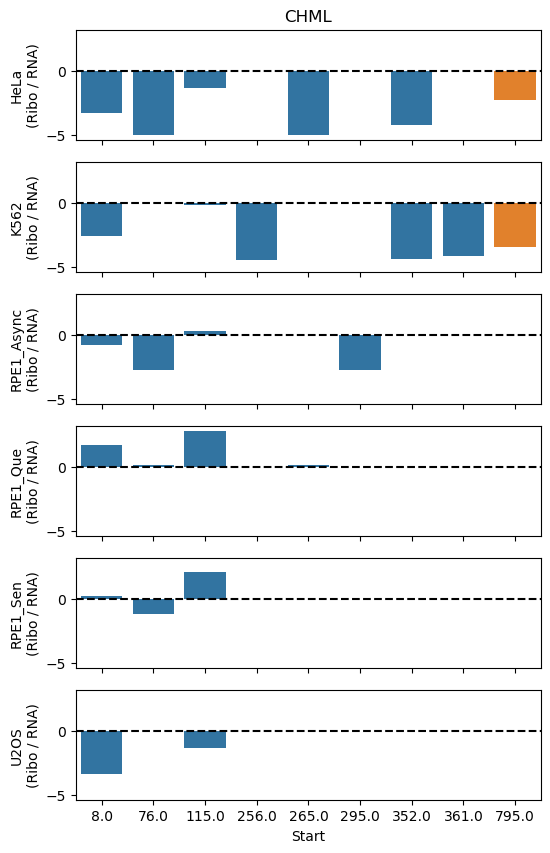

In [160]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000366553.3'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('CHML')

Text(0.5, 1.0, 'CD59')

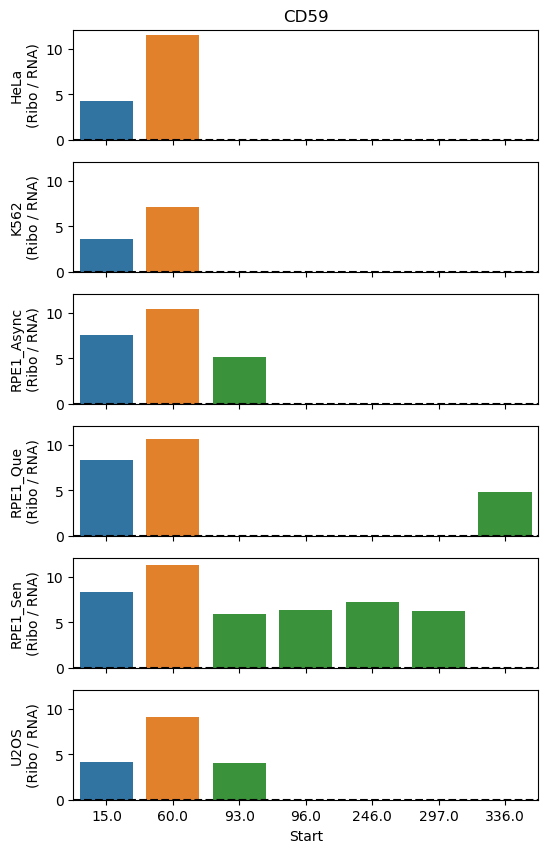

In [159]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000642928.2'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('CD59')

Text(0.5, 1.0, 'SRSF1')

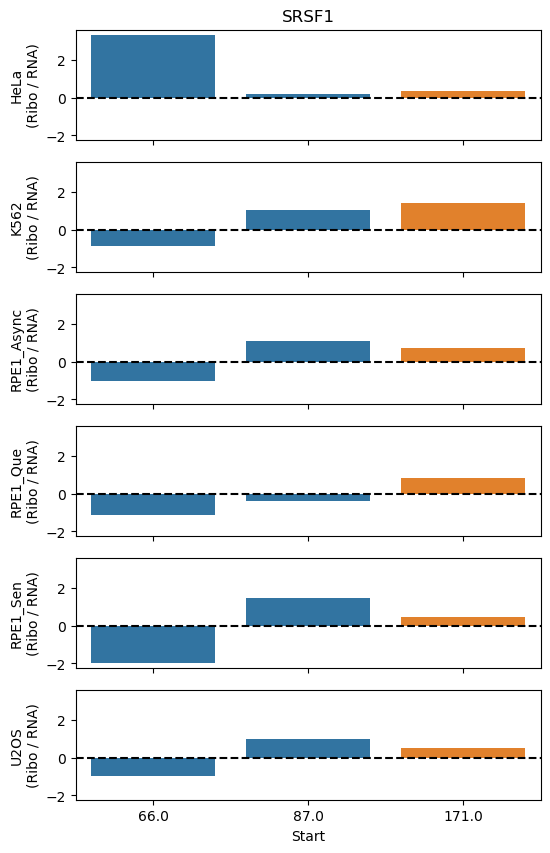

In [165]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000359995.10'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('SRSF1')

## Check for SLiM enrichment in the differential protein sequences between canonical and non-canonical starts

In [46]:
# sequence_differential_df = pair_canonical_isoforms(
#     sample_level_tis_df, id_columns=['Sample', 'Tid'], canonical_columns=['Start', 'StartCodon', 'AALen', 'AASeq'], downstream_calculations=False
# ).drop_duplicates(subset=['Tid', 'Start'])[['TIS', 'RecatTISType', 'Start', 'CanonicalStart',  'AASeq', 'CanonicalAASeq', 'AALen', 'CanonicalAALen']]

sequence_differential_df = pair_canonical_isoforms(
    replicate_level_tis_df, id_columns=['Sample', 'Tid'], canonical_columns=['Start', 'StartCodon', 'AALen', 'AASeq'], downstream_calculations=False
).drop_duplicates(subset=['Tid', 'Start'])[['TIS', 'RecatTISType', 'Start', 'CanonicalStart',  'AASeq', 'CanonicalAASeq', 'AALen', 'CanonicalAALen']].dropna(subset=['AASeq', 'CanonicalAASeq'])

In [47]:
differential_sequences = pd.concat([
    sequence_differential_df['TIS'],
    sequence_differential_df.apply(
        lambda x: x['AASeq'][:int(x['AALen'] - x['CanonicalAALen'])] if x['RecatTISType'] == 'Extended' else
            x['CanonicalAASeq'][:int(x['CanonicalAALen'] - x['AALen'])] if x['RecatTISType'] == 'Truncated' else
            x['AASeq'] if x['RecatTISType'] in ['uORF', 'Other'] else None,
        axis=1
    ).rename('AASeqDiffFromCanonical')
], axis=1)

In [48]:
slim_classes = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/external/elm_slim_classes.tsv', sep='\t', skiprows=5)

def scan_regex_patterns(series, pattern_df=slim_classes, id_colname='ELMIdentifier'):
    pattern_presence_matrix = []
    for i, r in tqdm(pattern_df.iterrows()):
        id_name = r[id_colname]
        pattern = r['Regex']
        pattern_presence_matrix.append(series.apply(lambda x: True if re.search(pattern, x) else False).rename(id_name))
    return pd.concat(pattern_presence_matrix, axis=1)

In [49]:
slim_presence_matrix = scan_regex_patterns(differential_sequences.set_index('TIS')['AASeqDiffFromCanonical'])

353it [02:27,  2.39it/s]


In [50]:
tis_i, slim_i = np.where(slim_presence_matrix)
slim_grouper_df = pd.DataFrame({'TIS_i': tis_i, 'SLiM_i': slim_i}).merge(
    pd.DataFrame({'TIS_i': range(slim_presence_matrix.shape[0]), 'TIS': slim_presence_matrix.index})
).merge(
    pd.DataFrame({'SLiM_i': range(slim_presence_matrix.shape[1]), 'SLiM': slim_presence_matrix.columns})
).merge(
    slim_classes, left_on=['SLiM'], right_on=['ELMIdentifier']
)

In [51]:
slim_ids = slim_grouper_df.groupby('TIS')['ELMIdentifier'].apply(list)
slim_func_names = slim_grouper_df.groupby('TIS')['FunctionalSiteName'].apply(lambda x: list(set(x)))
slim_descriptions = slim_grouper_df.groupby('TIS')['Description'].apply(lambda x: list(set(x)))

In [52]:
slim_analysis_df = differential_sequences.merge(
    pd.concat([slim_ids.apply(lambda x: '|'.join(x)).rename('AASeqDiff_ELMIdentifier'), 
               slim_func_names.apply(lambda x: '|'.join(x)).rename('AASeqDiff_FunctionSiteName'), 
               slim_descriptions.apply(lambda x: '|'.join(x)).rename('AASeqDiff_Description')], axis=1),
    left_on='TIS', right_index=True
)

In [33]:
slim_analysis_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/differential_aaseq_slim_analysis.csv', index=False)

In [ ]:
slim_analysis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/differential_aaseq_slim_analysis.csv')

## Separate tables into (1) Continuous variation across cell lines; and (6) Outliers for each cell line

### How to set good thresholds for outliers

(-5.0, 15.0)

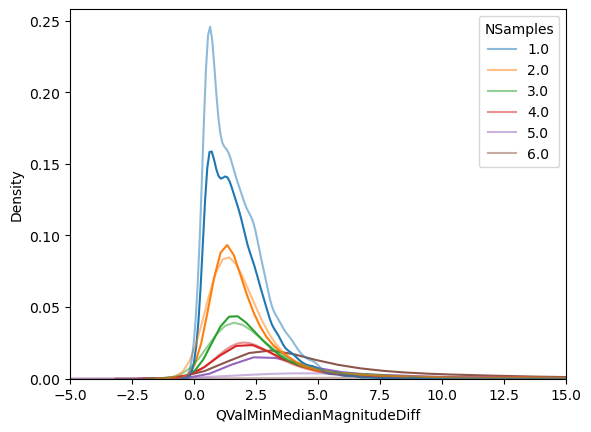

In [34]:
sns.kdeplot(
    tis_summary[tis_summary['MinDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples', palette='tab10'
)
sns.kdeplot(
    tis_summary[tis_summary['MedianDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples', palette='tab10', alpha=0.5
)
plt.xlim(-5, 15)

(-5.0, 25.0)

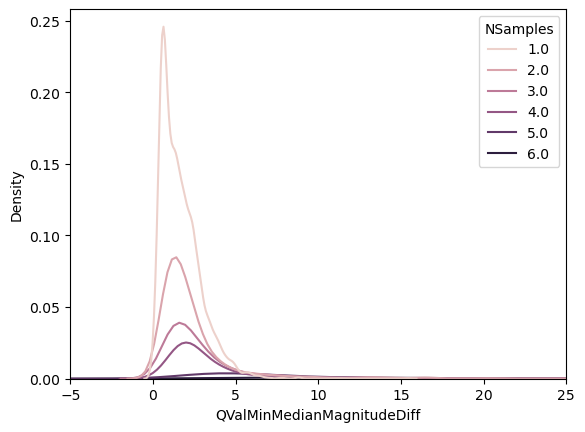

In [35]:
sns.kdeplot(
    tis_summary[tis_summary['MedianDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples'
)
plt.xlim(-5, 25)

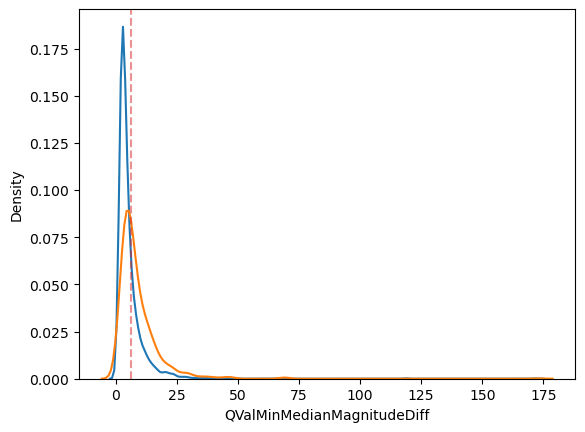

In [36]:
sns.kdeplot(
    tis_summary[(tis_summary['MinDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)], 
    x='QValMinMedianMagnitudeDiff',
)
sns.kdeplot(
    tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)], 
    x='QValMinMedianMagnitudeDiff',
)
plt.axvline(6, linestyle='dashed', color='tab:red', alpha=0.5)

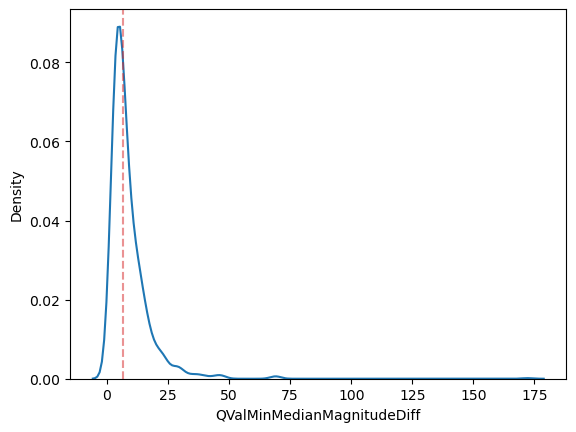

In [40]:
sns.kdeplot(
    tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)], 
    x='QValMinMedianMagnitudeDiff',
)
plt.axvline(
    np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)]['QValMinMedianMagnitudeDiff'], 0.5), 
    linestyle='dashed', color='tab:red', alpha=0.5
)

In [41]:
np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 6)]['QValMinMedianMagnitudeDiff'], 0.5)

np.float64(11.163555546683469)

In [394]:
def calculate_qval_magnitude_boundary(tis_summary, max_significance=0.01, min_samples=6):
    # sns.kdeplot(
    #     tis_summary[(tis_summary['MinDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
    #     x='QValMinMedianMagnitudeDiff', label='Min Q-value < 0.01 ("Outlier" or "Continuum")'
    # )
    # outlier_x, outlier_y = plt.gca().get_lines()[-1].get_data()
    # sns.kdeplot(
    #     tis_summary[(tis_summary['MedianDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
    #     x='QValMinMedianMagnitudeDiff', label='Median Q-value < 0.01 ("Continuum")'
    # )
    # trend_x, trend_y = plt.gca().get_lines()[-1].get_data()
    # midpoint_x = np.mean([trend_x[np.argmax(trend_y)], outlier_x[np.argmax(outlier_y)]])
    # plt.axvline(midpoint_x, linestyle='dashed', color='tab:red', alpha=0.5, label=f'Midpoint between modes ({midpoint_x:.2f})')
    # plt.legend()
    # plt.show()

    # return midpoint_x

    sns.kdeplot(
        tis_summary[(tis_summary['MedianDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
        x='QValMinMedianMagnitudeDiff', label='Median Q-value < 0.01 ("Continuum")'
    )
    q = np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)]['QValMinMedianMagnitudeDiff'], 0.5)
    plt.axvline(q, linestyle='dashed', color='tab:red', alpha=0.5, label=f'Midpoint between modes ({q:.2f})')
    plt.legend()
    plt.show()
    return q

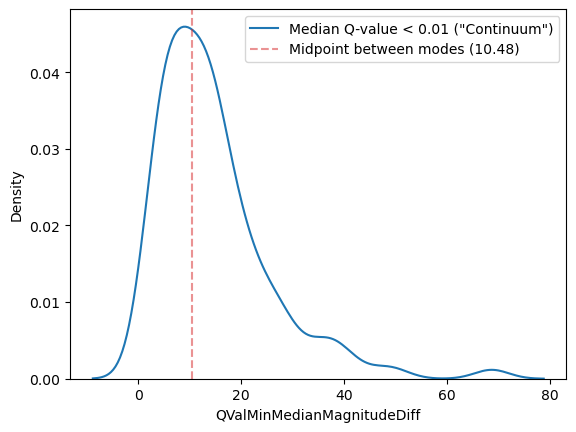

In [395]:
magnitude_boundary = calculate_qval_magnitude_boundary(tis_summary)

In [408]:
tis_summary[
    (tis_summary['QValMinMedianMagnitudeDiff'] > magnitude_boundary)# &
    # (tis_summary['MinDiffQValSamplePair'].str.contains(s))
]

,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,TEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxTE,MaxTESample,MinTE,MinTESample,MaxLFCSamplePair,MaxLFCSamplePair,MinLFC,MinLFCSamplePair,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff
1,ENST00000487214.1_90_chr1:959219:-,ENST00000487214.1:90,ENST00000487214.1,NOC2L,ENSG00000188976.12,protein_coding,AAG,90.0,Other,False,247.0,KRRLAELTVDEFLASGFDSESESESENSPQAETREAREAARSPDKP...,5.0,1.114432,54.0,1.033935,HeLa,54.0,1.033935,HeLa,-0.585882,HeLa,-3.504089,K562,3.911677,U2OS/RPE1_Que,-5.041559,RPE1_Que/HeLa,2.151207e-13,K562/HeLa,0.061848,1.00000,11.458646
40,ENST00000488042.6_39_chr1:1324590:-,ENST00000488042.6:39,ENST00000488042.6,INTS11,ENSG00000127054.23,protein_coding,ACG,39.0,Other,False,277.0,TPLGAGQDVGRSCILVSIAGKNVMLDCGMHMGFNDDRRFPDFSYIT...,5.0,3.547189,37.0,0.840946,RPE1_Async,17.0,0.708437,HeLa,-0.299866,HeLa,-4.781816,K562,4.300961,RPE1_Async/K562,-5.890639,RPE1_Que/HeLa,2.845612e-19,K562/HeLa,0.021854,1.00000,16.885358
65,ENST00000291386.4_306_chr1:1574557:-,ENST00000291386.4:306,ENST00000291386.4,SSU72,ENSG00000160075.13,protein_coding,ATG,306.0,Annotated,True,194.0,MPSSPLRVAVVCSSNQNRSMEAHNILSKRGFSVRSFGTGTHVKLPG...,6.0,2.582603,154.0,2.948630,HeLa,12.0,1.123297,RPE1_Que,1.328189,HeLa,-3.123195,RPE1_Sen,1.867186,U2OS/RPE1_Sen,-4.740931,RPE1_Sen/HeLa,1.469106e-24,K562/HeLa,0.071759,1.00000,22.688824
66,ENST00000378725.3_30_chr1:1574557:-,ENST00000378725.3:30,ENST00000378725.3,SSU72,ENSG00000160075.13,protein_coding,ATG,30.0,Other,False,162.0,MPSSPLRVAVVCSSNQNRSMEAHNILSKRGFSVRSFGTGTHVKLPG...,6.0,2.582603,154.0,2.948630,HeLa,12.0,1.123297,RPE1_Que,1.328189,HeLa,-3.123195,RPE1_Sen,1.867186,U2OS/RPE1_Sen,-4.740931,RPE1_Sen/HeLa,1.469106e-24,K562/HeLa,0.071759,1.00000,22.688824
250,ENST00000377038.8_113_chr1:10472416:-,ENST00000377038.8:113,ENST00000377038.8,DFFA,ENSG00000160049.13,protein_coding,ATC,113.0,Truncated,True,317.0,IRTLKPCLLRRNYSREQHGVAASCLEDLRSKACDILAIDKSLTPVT...,4.0,1.217142,58.0,1.624298,K562,5.0,0.188079,RPE1_Sen,0.340373,HeLa,-1.926620,K562,1.810682,RPE1_Sen/RPE1_Que,-4.106870,RPE1_Que/HeLa,4.004175e-13,K562/HeLa,0.681763,1.00000,12.231121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247217,ENST00000550657.1_59_chr12:93441884:-,ENST00000550657.1:59,ENST00000550657.1,UBE2N,ENSG00000177889.11,protein_coding,ATG,59.0,Annotated,False,152.0,MAGLPRRIIKETQRLLAEPVPGIKAEPDESNARYFHVVIAGPQDSP...,4.0,2.357901,396.0,14.618678,K562,0.0,0.000000,U2OS,5.214190,HeLa,1.760358,RPE1_Que,2.527201,RPE1_Sen/RPE1_Que,-3.434159,RPE1_Que/HeLa,5.558386e-29,K562/HeLa,0.617075,1.00000,28.045389
247417,ENST00000553300.6_207_chr14:21234193:-,ENST00000553300.6:207,ENST00000553300.6,HNRNPC,ENSG00000092199.20,protein_coding,ATG,207.0,Annotated,True,293.0,MASNVTNKTDPRSMNSRVFIGNLNTLVVKKSDVEAIFSKYGKIVGC...,4.0,1.862618,1832.0,67.629843,K562,0.0,0.000000,U2OS,4.023583,HeLa,0.858539,RPE1_Que,3.542166,RPE1_Sen/RPE1_Que,-3.993084,RPE1_Que/RPE1_Async,5.139386e-21,RPE1_Que/HeLa,0.361541,0.94066,19.847247
247419,ENST00000556309.5_19_chr14:21383927:-,ENST00000556309.5:19,ENST00000556309.5,SUPT16H,ENSG00000092201.11,protein_coding,ATG,19.0,Annotated,False,66.0,MAVTLDKDAYYRRVKRLYSNWRKGEDEYANVDAIVVSVGVDEEIVY...,6.0,2.243109,94.0,3.470090,K562,0.0,0.000000,U2OS,0.585365,HeLa,-3.366698,RPE1_Async,1.236362,RPE1_Que/RPE1_Async,-4.094579,RPE1_Async/HeLa,4.743739e-17,K562/HeLa,0.106034,1.00000,15.349325
247422,ENST00000535847.1_63_chr14:22589157:-,ENST00000535847.1:63,ENST00000535847.1,DAD1,ENSG00000129562.12,protein_coding,ATG,63.0,Annotated,False,65.0,MSASVVSVISRFLEEYLSSTPQRLKLLDAYLLYILLTGALHLPENT...,3.0,3.690629,56.0,3.369890,RPE1_Que,0.0,0.000000,U2OS,2.362890,HeLa,-1.060508,K562,6.765685,U2OS/K562,-5.708324,RPE1_Que/RPE1_Async,6.088653e-31,K562/HeLa,0.041162,0.90860,2

In [20]:
tis_summary[(tis_summary['QValMinMedianMagnitudeDiff'] > 10)].sort_values(
    'LeaveOneOutLargestDeltaVariance', ascending=False).query('RecatTISType.isin(["Extended", "Truncated"])')

,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,LogTEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair.1,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,LeaveOneOutLargestDeltaVariance,CandidateOutlier
26187,ENST00000369632.6_394_chr1:112705122:-,ENST00000369632.6:394,ENST00000369632.6,RHOC,ENSG00000155366.18,protein_coding,CTG,394.0,Extended,False,203.0,LGTSAGWSPTMAAIRKKLVIVGDGACGKTCLLIVFSKDQFPEVYVP...,6.0,0.672800,256,12.663652,RPE1_Async,23,0.440380,HeLa,0.898680,RPE1_Async,-1.060938,K562,2.027611,RPE1_Async/HeLa,-1.582188,RPE1_Que/RPE1_Async,1.0,2.127735e-15,RPE1_Async/K562,0.001863,1.000000,11.942186,-0.184146,RPE1_Async
26180,ENST00000369633.6_270_chr1:112705122:-,ENST00000369633.6:270,ENST00000369633.6,RHOC,ENSG00000155366.18,protein_coding,CTG,270.0,Extended,False,203.0,LGTSAGWSPTMAAIRKKLVIVGDGACGKTCLLIVFSKDQFPEVYVP...,6.0,0.672800,256,12.663652,RPE1_Async,23,0.440380,HeLa,0.898680,RPE1_Async,-1.060938,K562,2.027611,RPE1_Async/HeLa,-1.582188,RPE1_Que/RPE1_Async,1.0,2.127735e-15,RPE1_Async/K562,0.001863,1.000000,11.942186,-0.184146,RPE1_Async
1194,ENST00000285735.6_1180_chr1:112705122:-,ENST00000285735.6:1180,ENST00000285735.6,RHOC,ENSG00000155366.18,protein_coding,CTG,1180.0,Extended,False,203.0,LGTSAGWSPTMAAIRKKLVIVGDGACGKTCLLIVFSKDQFPEVYVP...,6.0,0.672800,256,12.663652,RPE1_Async,23,0.440380,HeLa,0.898680,RPE1_Async,-1.060938,K562,2.027611,RPE1_Async/HeLa,-1.582188,RPE1_Que/RPE1_Async,1.0,2.127735e-15,RPE1_Async/K562,0.001863,1.000000,11.942186,-0.184146,RPE1_Async
3794,ENST00000440838.5_100_chr2:231056974:+,ENST00000440838.5:100,ENST00000440838.5,PSMD1,ENSG00000173692.15,protein_coding,CTG,100.0,Extended,False,220.0,LRSWNGERADGRVRGAAMITSAAGIISLLDEDEPQLKEFALHKLNA...,6.0,0.281413,572,13.215875,K562,48,4.493186,RPE1_Que,0.664794,HeLa,-0.706789,RPE1_Que,0.701940,RPE1_Sen/RPE1_Que,-1.351537,RPE1_Que/HeLa,-1.0,9.664858e-19,K562/HeLa,0.058091,1.000000,16.778916,-0.200010,HeLa
3791,ENST00000308696.11_108_chr2:231056974:+,ENST00000308696.11:108,ENST00000308696.11,PSMD1,ENSG00000173692.15,protein_coding,CTG,108.0,Extended,True,970.0,LRSWNGERADGRVRGAAMITSAAGIISLLDEDEPQLKEFALHKLNA...,6.0,0.281413,572,13.215875,K562,48,4.493186,RPE1_Que,0.664794,HeLa,-0.706789,RPE1_Que,0.701940,RPE1_Sen/RPE1_Que,-1.351537,RPE1_Que/HeLa,-1.0,9.664858e-19,K562/HeLa,0.058091,1.000000,16.778916,-0.200010,HeLa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15800,ENST00000260383.11_110_chr15:43371210:+,ENST00000260383.11:110,ENST00000260383.11,TUBGCP4,ENSG00000137822.14,protein_coding,TTG,110.0,Extended,False,715.0,LSRWVDSAQTARPRGRCACGRGSTPLVVAWRCAGGGGDITRDSRSA...,2.0,9.165774,188,3.599627,HeLa,0,0.000000,RPE1_Que,0.451223,HeLa,-3.830312,K562,0.760997,RPE1_Que/K562,-6.604624,U2OS/HeLa,-1.0,6.457855e-14,K562/HeLa,0.011669,1.000000,11.256955,-inf,HeLa
11986,ENST00000530596.5_33_chr11:47176835:-,ENST00000530596.5:33,ENST00000530596.5,ARFGAP2,ENSG00000149182.16,protein_coding,AAG,33.0,Truncated,False,167.0,KTEIQTLFKRLRAVPTNKACFDCGAKNPSWASITYGVFLCIDCSGV...,2.0,6.607972,109,2.087018,HeLa,0,0.000000,RPE1_Async,0.268238,HeLa,-3.367136,K562,-0.419283,U2OS/K562,-7.200632,RPE1_Async/HeLa,-1.0,5.514428e-20,K562/HeLa,0.000188,0.893081,15.532684,-inf,HeLa
34842,ENST00000358344.8_132_chr5:178204664:+,ENST00000358344.8:132,ENST00000358344.8,HNRNPAB,ENSG00000197451.13,protein_coding,TTG,132.0,Extended,True,365.0,LSAAEPAAPSPAGGDERAPRRHRRRGAAAPRPSMSEAGEEQPMETT...,2.0,2.806931,488,18.014936,K562,0,0.000000,RPE1_Async,-0.664558,K562,-3.033917,HeLa,8.841895,U2OS/HeLa,2.366245,K562/HeLa,1.0,6.853045e-16,K562/HeLa,0.001284,0.046543,12.272673,-inf,HeLa
34844,ENST00000355836.9_126_chr5:178

In [57]:
tis_summary[(tis_summary['Symbol'] == 'ACTG1')].sort_values(
    'LeaveOneOutLargestDeltaVariance', ascending=False).query('RecatTISType.isin(["Extended", "Truncated"])')

,TIS,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,LogTEVariance,MaxRiboseqCounts,MaxRiboseqRPM,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqRPM,MinRiboseqSample,MaxLogRiboOverRNA,MaxLogTESample,MinLogRiboOverRNA,MinLogTESample,MaxLFCSamplePair,MaxLFCSamplePair,MinLFC,MinLFCSamplePair,MinDiffQValDirection,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal,MaxDiffQVal,QValMinMedianMagnitudeDiff,LeaveOneOutLargestDeltaVariance,CandidateOutlier
199846,ENST00000575994.6_818_chr17:81511383:-,ENST00000575994.6,ACTG1,ENSG00000184009.14,protein_coding,ACG,818.0,Truncated,False,173.0,TAEREIVRDIKEKLCYVALDFEQEMATAASSSSLEKSYELPDGQVI...,3.0,0.059405,160,9.922453,RPE1_Que,0,0.000000,RPE1_Async,-4.014324,HeLa,-4.471729,RPE1_Que,10.294537,U2OS/RPE1_Que,-9.367980,RPE1_Que/RPE1_Async,1.0,1.100763e-05,U2OS/K562,0.000214,0.999234,1.289065,-0.055981,RPE1_Que
199844,ENST00000575659.6_706_chr17:81511383:-,ENST00000575659.6,ACTG1,ENSG00000184009.14,protein_coding,ACG,706.0,Truncated,False,173.0,TAEREIVRDIKEKLCYVALDFEQEMATAASSSSLEKSYELPDGQVI...,3.0,0.059405,160,9.922453,RPE1_Que,0,0.000000,RPE1_Async,-4.014324,HeLa,-4.471729,RPE1_Que,10.294537,U2OS/RPE1_Que,-9.367980,RPE1_Que/RPE1_Async,1.0,1.100763e-05,U2OS/K562,0.000214,0.999234,1.289065,-0.055981,RPE1_Que
21762,ENST00000573283.7_60_chr17:81512739:-,ENST00000573283.7,ACTG1,ENSG00000184009.14,protein_coding,CTG,60.0,Extended,True,379.0,LPVAMEEEIAALVIDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQG...,6.0,0.383678,3596,177.884742,RPE1_Async,404,17.002492,HeLa,-0.101469,RPE1_Async,-1.567428,HeLa,1.428038,RPE1_Async/HeLa,-1.409555,RPE1_Que/RPE1_Async,1.0,9.276866e-03,RPE1_Async/HeLa,0.580290,1.000000,1.796244,-0.157987,RPE1_Async
21768,ENST00000571691.6_60_chr17:81512739:-,ENST00000571691.6,ACTG1,ENSG00000184009.14,protein_coding,CTG,60.0,Extended,False,355.0,LPVAMEEEIAALVIDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQG...,6.0,0.456688,3596,177.884742,RPE1_Async,294,17.002492,HeLa,-0.101469,RPE1_Async,-1.678515,U2OS,1.427987,RPE1_Async/HeLa,-1.536867,U2OS/RPE1_Async,1.0,9.863351e-03,RPE1_Async/HeLa,0.198432,1.000000,1.303588,-0.187581,RPE1_Async
117813,ENST00000575842.5_448_chr17:81512333:-,ENST00000575842.5,ACTG1,ENSG00000184009.14,protein_coding,CTG,448.0,Truncated,False,368.0,LVIDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGMGQKDSY...,4.0,1.027264,1240,27.666724,U2OS,0,0.000000,RPE1_Async,-1.107075,HeLa,-3.229817,RPE1_Que,7.667288,RPE1_Sen/RPE1_Que,-8.118206,RPE1_Que/RPE1_Async,1.0,2.550136e-03,RPE1_Async/K562,0.034658,0.638497,1.133241,-0.335393,HeLa
117820,ENST00000575659.6_121_chr17:81512333:-,ENST00000575659.6,ACTG1,ENSG00000184009.14,protein_coding,CTG,121.0,Truncated,False,368.0,LVIDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGMGQKDSY...,4.0,1.027264,1240,27.666724,U2OS,0,0.000000,RPE1_Async,-1.107075,HeLa,-3.229817,RPE1_Que,7.667288,RPE1_Sen/RPE1_Que,-8.118206,RPE1_Que/RPE1_Async,1.0,2.550136e-03,RPE1_Async/K562,0.034658,0.638497,1.133241,-0.335393,HeLa
117822,ENST00000575994.6_233_chr17:81512333:-,ENST00000575994.6,ACTG1,ENSG00000184009.14,protein_coding,CTG,233.0,Truncated,False,368.0,LVIDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGMGQKDSY...,4.0,1.027264,1240,27.666724,U2OS,0,0.000000,RPE1_Async,-1.107075,HeLa,-3.229817,RPE1_Que,7.667288,RPE1_Sen/RPE1_Que,-8.118206,RPE1_Que/RPE1_Async,1.0,2.550136e-03,RPE1_Async/K562,0.034658,0.638497,1.133241,-0.335393,HeLa
117809,ENST00000615544.5_74_chr17:81512333:-,ENST00000615544.5,ACTG1,ENSG00000184009.14,protein_coding,CTG,74.0,Truncated,False,368.0,LVIDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGMGQKDSY...,4.0,1.027264,1240,27.666724,U2OS,0,0.000000,RPE1_Async,-1.107075,HeLa,-3.229817,RPE1_Que,7.667288,RPE1_Sen/RPE1_Que,-8.118206,RPE1_Que/RPE1_Async,1.0,2.550136e-03,RPE1_Async/K562,0.034658,0.638497,1.133241,-0.335393,HeLa
199838,ENST00000575842.5_1033_chr17:81511383:-,ENST00000575842.5,ACTG1,ENSG00000184009.14,protein_coding,ACG,1033.0,Truncated,False,173.0,TAEREIVRDIKEKLCYVALDFEQEMATAASSSSLEKSYELPDGQVI...,4.0,0.547179,354,13.315959,RPE1_Sen,0,0.000000,RPE1_Async,-2.769490,RPE1_

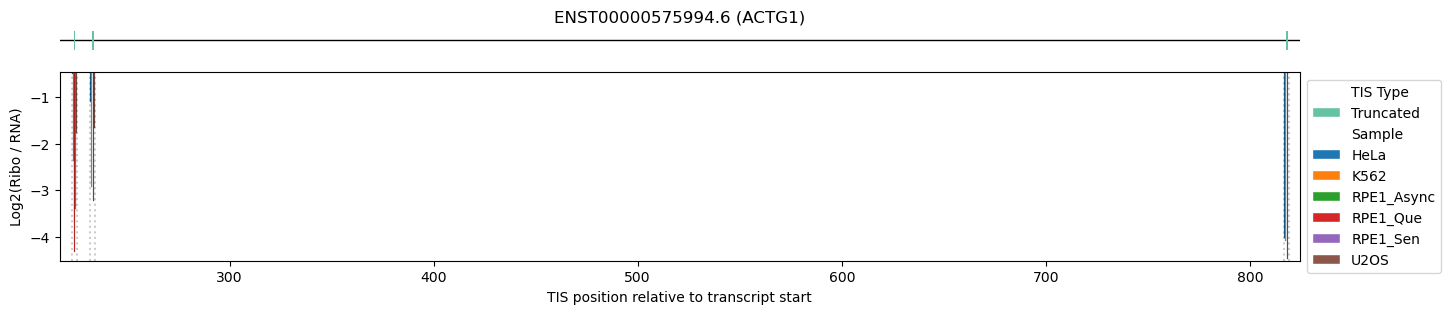

In [56]:
plot_tis_over_cell_lines('ENST00000575994.6')

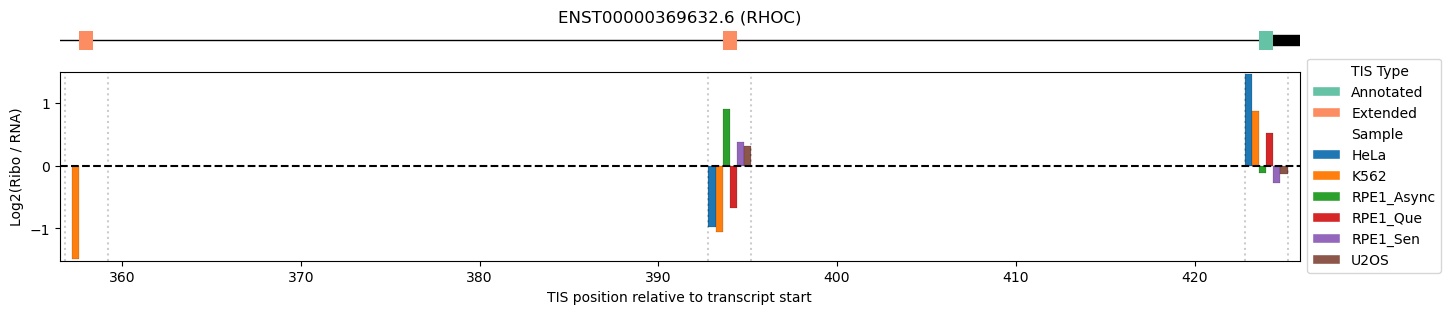

In [166]:
plot_tis_over_cell_lines('ENST00000369632.6')

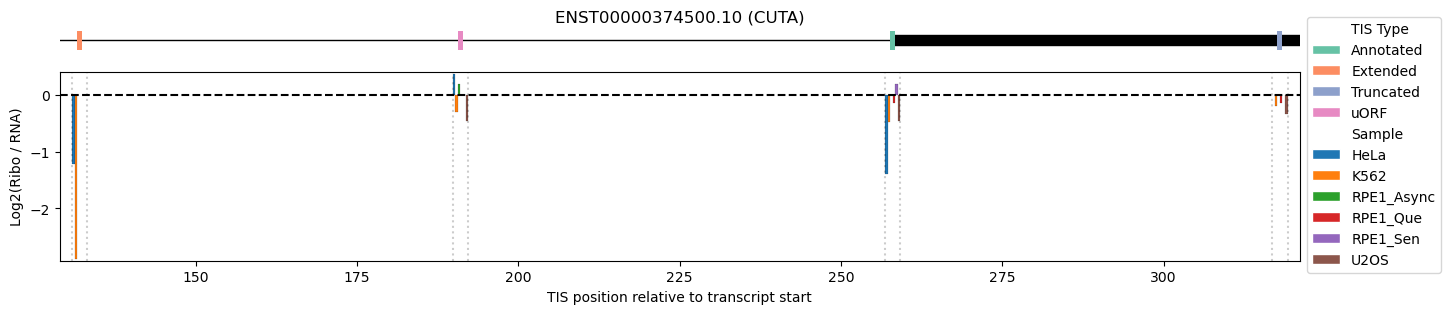

In [168]:
plot_tis_over_cell_lines('ENST00000374500.10')

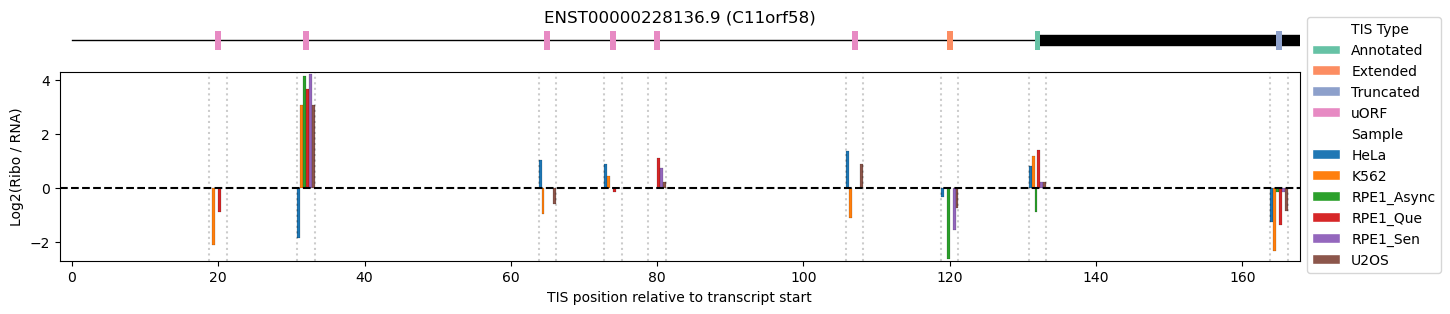

In [164]:
plot_tis_over_cell_lines('ENST00000228136.9')

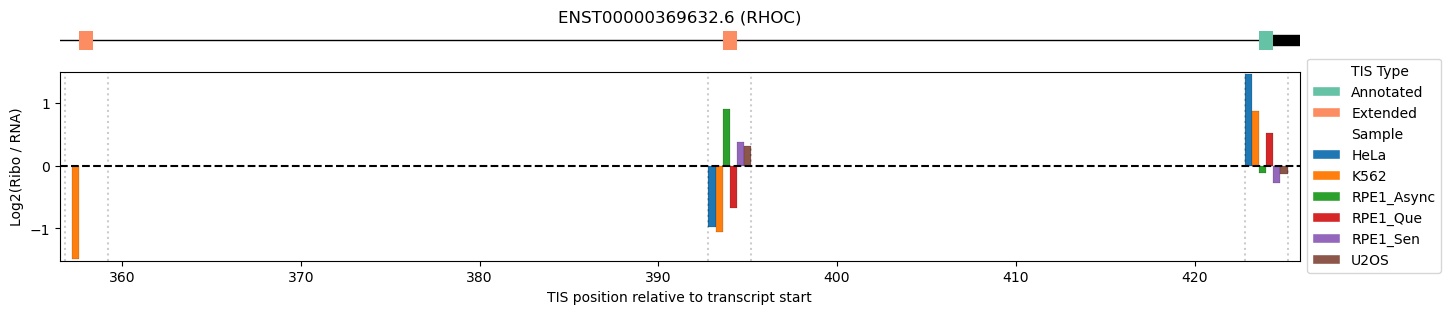

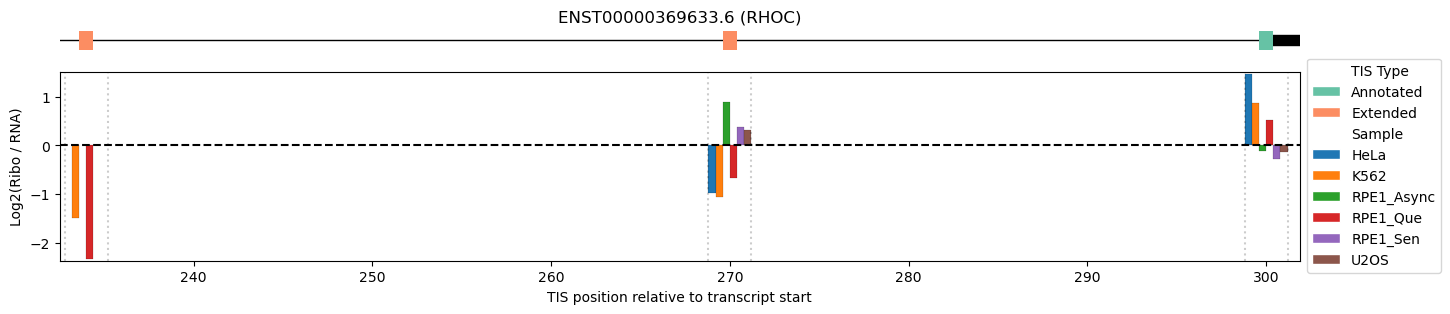

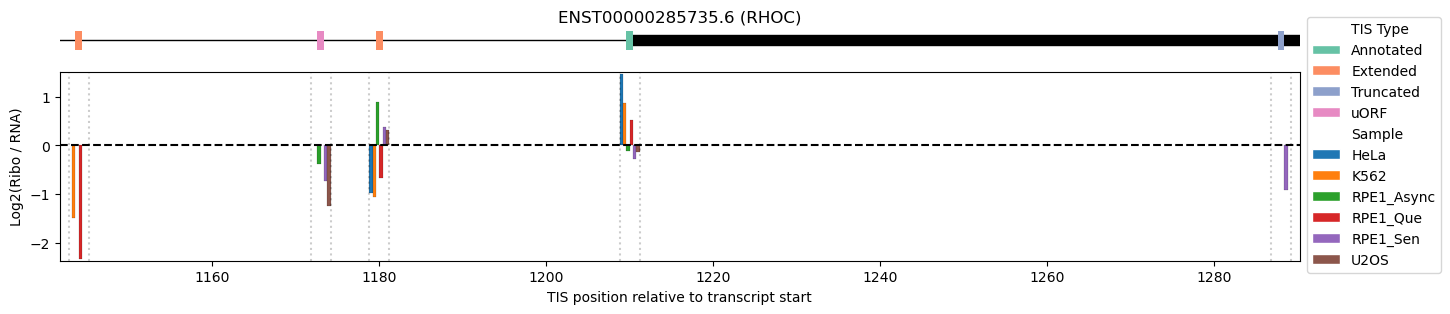

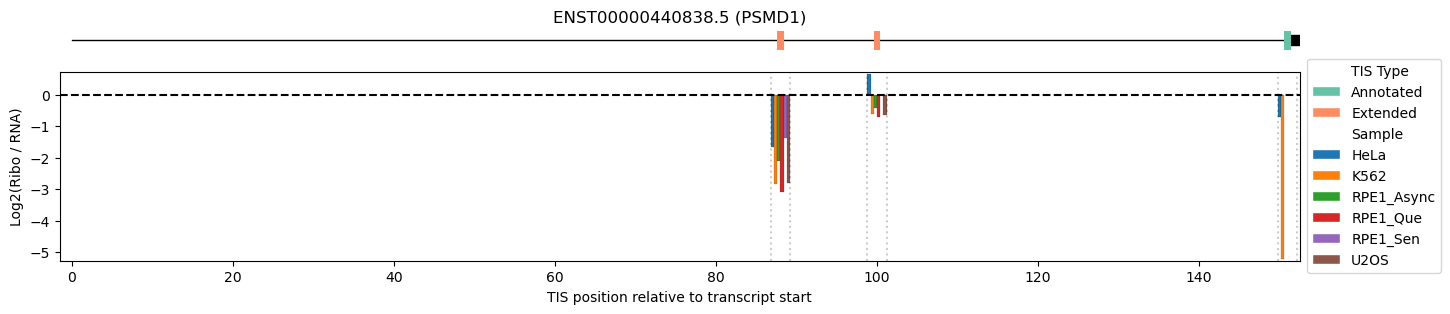

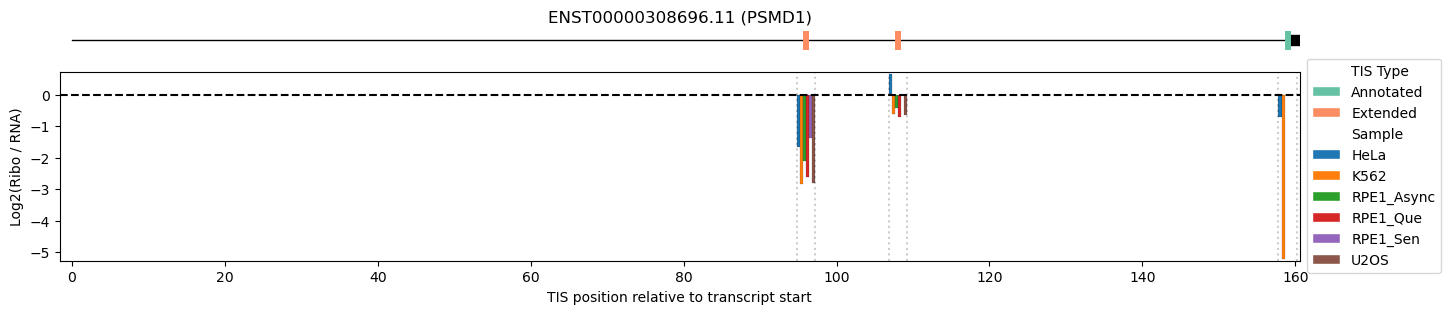

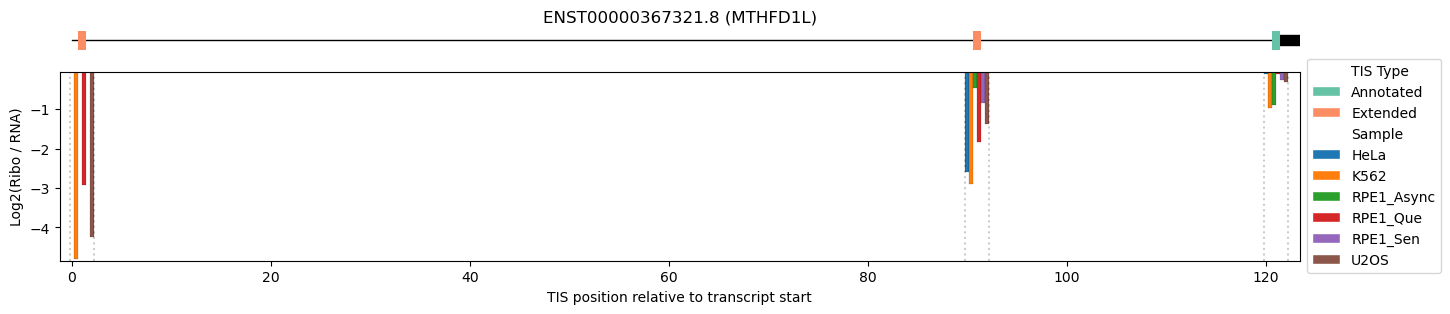

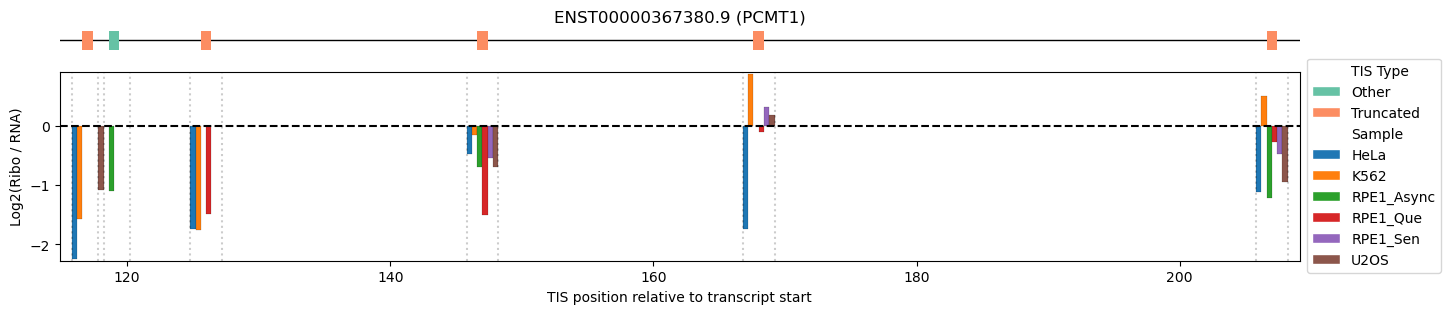

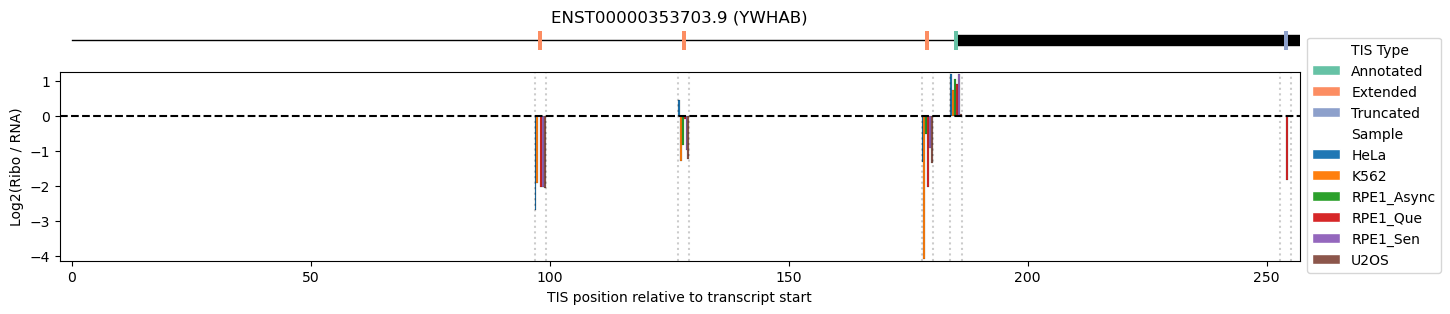

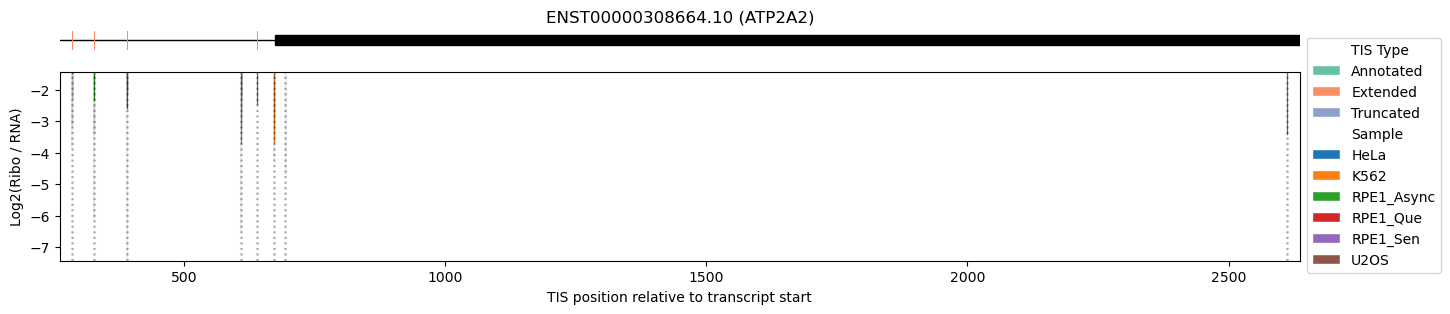

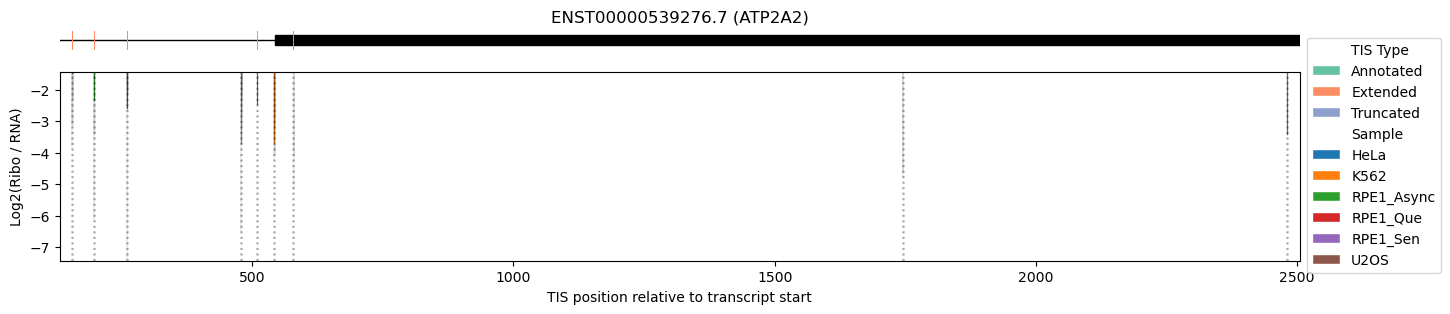

In [170]:
for t in tis_summary[(tis_summary['QValMinMedianMagnitudeDiff'] > 10)].sort_values(
    'LeaveOneOutLargestDeltaVariance', ascending=False).query('RecatTISType.isin(["Extended", "Truncated"])')['Tid'].head(10).unique().tolist():
    plot_tis_over_cell_lines(t)

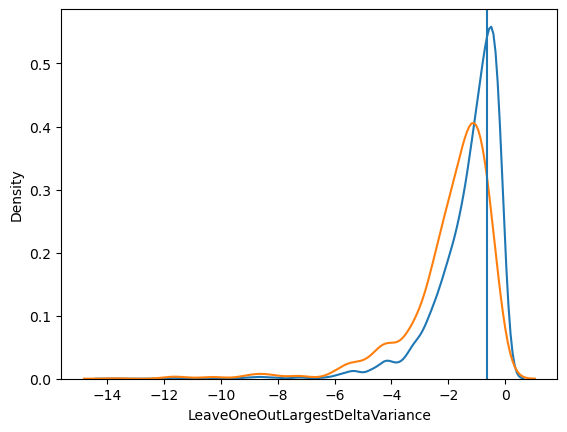

In [42]:
sns.kdeplot(tis_summary[(tis_summary['QValMinMedianMagnitudeDiff'] > 5)], x='LeaveOneOutLargestDeltaVariance')
sns.kdeplot(tis_summary[(tis_summary['QValMinMedianMagnitudeDiff'] > 10)], x='LeaveOneOutLargestDeltaVariance')
plt.gca().axvline(-0.63)

In [ ]:
# qval_magnitude_diff = 5
# outlier_df = []
# for s in samples:
#     if s == 'HeLa':
#         outlier_subset = tis_summary[
#             ((tis_summary['QValMinMedianMagnitudeDiff'] > qval_magnitude_diff) & # requirement for outlier
#              ((tis_summary['MinDiffQValDirection'] < 0) & # first cell line is a negative outlier or second cell line is a positive outlier
#               ((tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MinLogTESample'] == s)) | 
#                (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MaxLogTESample'] == s))) |
#               ((tis_summary['MinDiffQValDirection'] > 0) & # first cell line is a positive outlier or second cell line is a negative outlier
#                (tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MaxLogTESample'] == s)) |
#                (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MinLogTESample'] == s))))) |
#             (tis_summary['NSamples'] == 1) & (tis_summary['MaxDiffQVal'] < 0.01) & (tis_summary['MaxRiboseqSample'] == s)
#         ]
#         outlier_subset = outlier_subset.assign(LikelyOutlier=s)
#     else:
#         outlier_subset = tis_summary[
#             ((tis_summary['QValMinMedianMagnitudeDiff'] > qval_magnitude_diff) & # requirement for outlier
#              ((tis_summary['MinDiffQValDirection'] < 0) & # first cell line is a negative outlier or second cell line is a positive outlier
#               ((tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MinLogTESample'] == s)) | 
#                (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MaxLogTESample'] == s))) |
#               ((tis_summary['MinDiffQValDirection'] > 0) & # first cell line is a positive outlier or second cell line is a negative outlier
#                (tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MaxLogTESample'] == s)) |
#                (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MinLogTESample'] == s)))) &
#              (~tis_summary['MinDiffQValSamplePair'].str.contains('HeLa'))) |
#             (tis_summary['NSamples'] == 1) & (tis_summary['MaxDiffQVal'] < 0.01) & (tis_summary['MaxRiboseqSample'] == s)
#         ]
#         outlier_subset = outlier_subset.assign(LikelyOutlier=s)
#     print(s, len(outlier_subset))
#     outlier_df.append(outlier_subset)
# outlier_df = pd.concat(outlier_df, axis=0)
# outlier_df = outlier_df[~(outlier_df['RecatTISType'].isin(['Annotated']))]

HeLa 6885
K562 445
RPE1_Async 227
RPE1_Que 651
RPE1_Sen 189
U2OS 126


In [88]:
qval_magnitude_diff = 10
min_outlier_effect_size = np.log2(2) # 2x foldchange
max_min_qval = 0.01
min_range_shift = np.log2(1.5) # 1.5x foldchange more than next largest

outlier_df = tis_summary[
    ((tis_summary['NSamples'] >= 3) & # outlier from other defined samples
     (tis_summary['QValMinMedianMagnitudeDiff'] > max(qval_magnitude_diff, -np.log10(max_min_qval))) &
     (tis_summary['LeaveOneOutLargestDeltaRange'].abs() > min_range_shift) &
     (((tis_summary['CandidateOutlier'] == tis_summary['MaxLogTESample']) &  # figure out whether it is a positive or negative outlier and threshold the corresponding one
       (tis_summary['MaxLogRiboOverRNA'].abs() >= min_outlier_effect_size)) |
      ((tis_summary['CandidateOutlier'] == tis_summary['MinLogTESample']) & 
       (tis_summary['MinLogRiboOverRNA'].abs() >= min_outlier_effect_size)))) |
    ((tis_summary['NSamples'] == 1) & # outlier because only one sample detected
     (tis_summary['MinDiffQVal'] <= max_min_qval) &
     (tis_summary['MaxLogRiboOverRNA'].abs() >= min_outlier_effect_size)) # only one value defined - this value is both max and min
]
outlier_df = outlier_df[~outlier_df['RecatTISType'].isin(['Annotated'])]

In [91]:
dropped_ranges

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
TIS,,,,,,
ENST00000327044.7_16_chr1:959240:-,1.011487,2.140705,2.140705,2.140705,1.766168,2.140705
ENST00000487214.1_90_chr1:959219:-,1.736187,1.746095,2.906992,2.906992,2.906992,2.906992
ENST00000624697.4_245_chr1:1013998:+,1.053999,0.729973,1.783973,1.783973,1.783973,1.783973
ENST00000649529.1_50_chr1:1013546:+,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
ENST00000360001.12_263_chr1:1228793:-,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
ENST00000447601.7_189_chrX:154516043:-,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
ENST00000621967.4_199_chrX:154516043:-,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
ENST00000475423.1_132_chrX:154764900:+,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [80]:
func_annotated_outlier_df = outlier_df.merge(slim_analysis_df, how='left')
func_annotated_outlier_df = func_annotated_outlier_df.sort_values(by=['NSamples', 'LogTEVariance'], ascending=[False, False])

In [81]:
func_annotated_outlier_df['LeaveOneOutLargestDeltaRange']

942     -1.793522
1657    -1.689613
1658    -1.689613
10178   -1.689613
10179   -1.689613
           ...   
16084         NaN
16085         NaN
16086         NaN
16087         NaN
16088         NaN
Name: LeaveOneOutLargestDeltaRange, Length: 16089, dtype: float64

In [59]:
variance_shifts.loc['ENST00000321358.12_88_chr1:42682505:+']

HeLa         -0.051406
K562          0.010038
RPE1_Async    0.000000
RPE1_Que     -0.006289
RPE1_Sen     -0.007815
U2OS          0.055471
Name: ENST00000321358.12_88_chr1:42682505:+, dtype: float64

In [58]:
dropped_variances.loc['ENST00000321358.12_88_chr1:42682505:+']

HeLa          0.119757
K562          0.181201
RPE1_Async    0.171162
RPE1_Que      0.164873
RPE1_Sen      0.163348
U2OS          0.226633
Name: ENST00000321358.12_88_chr1:42682505:+, dtype: float64

In [57]:
func_annotated_outlier_df.loc[1994]

TIS                                            ENST00000321358.12_88_chr1:42682505:+
Tid                                                               ENST00000321358.12
Symbol                                                                          YBX1
Gid                                                               ENSG00000065978.20
GeneType                                                              protein_coding
StartCodon                                                                       ATC
Start                                                                           88.0
RecatTISType                                                                Extended
MANE_Select                                                                     True
AALen                                                                          344.0
AASeq                              ITPREEPQLPQPAPVTITATMSSEAETQQPPAAPPAAPALSAADTK...
NSamples                                                         

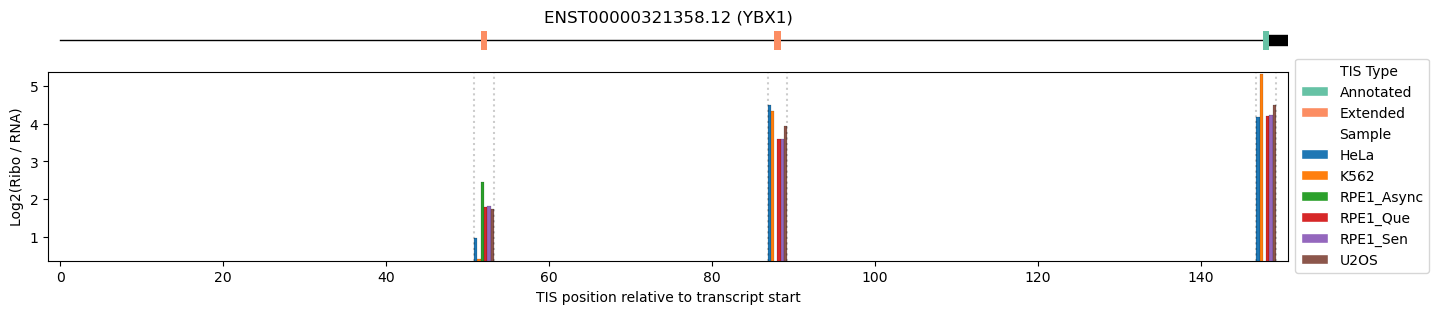

In [52]:
plot_tis_over_cell_lines(func_annotated_outlier_df.loc[1994].loc['Tid'], tis_summary, masked_te_matrix)

In [60]:
func_annotated_outlier_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/alternative_translation_efficiency_outliers.csv')

In [61]:
qval_magnitude_diff = 5
max_median_qval = 0.01
min_samples = 3

continuum_df = tis_summary[
    (tis_summary['QValMinMedianMagnitudeDiff'] < qval_magnitude_diff) &
    (tis_summary['MedianDiffQVal'] < max_median_qval) & 
    (tis_summary['NSamples'] >= min_samples) &
    ~(tis_summary['RecatTISType'].isin(['Annotated']))
]

In [62]:
func_annotated_continuum_df = continuum_df.merge(slim_analysis_df, how='left')
func_annotated_continuum_df = func_annotated_continuum_df.sort_values(by=['NSamples', 'LogTEVariance'], ascending=[False, False])

In [63]:
func_annotated_continuum_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/alternative_translation_efficiency_continuous.csv')

In [66]:
tis_summary['Class'] = 'None'
tis_summary.loc[tis_summary['TIS'].isin(func_annotated_outlier_df['TIS'].tolist()), 'Class'] = 'Outlier'
tis_summary.loc[tis_summary['TIS'].isin(func_annotated_continuum_df['TIS'].tolist()), 'Class'] = 'Continuous'
tis_summary.value_counts('Class')

Class
None          90482
Outlier        9818
Continuous     1684
Name: count, dtype: int64

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
TIS,,,,,,
ENST00000327044.7_16_chr1:959240:-,True,True,True,True,True,True
ENST00000487214.1_90_chr1:959219:-,True,True,True,False,True,True
ENST00000624697.4_245_chr1:1013998:+,True,True,False,False,False,True
ENST00000649529.1_50_chr1:1013546:+,True,False,False,False,False,False
ENST00000360001.12_263_chr1:1228793:-,True,False,False,False,False,False
...,...,...,...,...,...,...
ENST00000621967.4_199_chrX:154516043:-,False,False,False,False,False,True
ENST00000475423.1_132_chrX:154764900:+,False,False,False,False,False,True
ENST00000369462.5_37_chrX:155071539:+,False,False,False,False,False,True


C11orf58 [32.0, 65.0]
ATP2A2 [261.0, 156.0, 198.0, 510.0, 2481.0]
CHML [8.0, 115.0, 256.0, 361.0]
HK1 [47.0, 185.0]
CFAP20 [73.0]
PTP4A1 [201.0]
MYH9 [5070.0]
SPCS1 [102.0]
RBM39 [273.0]


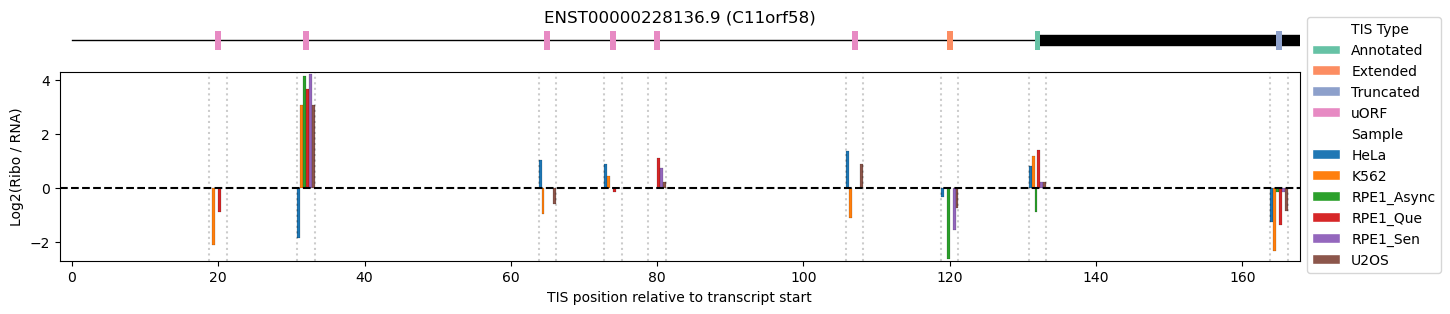

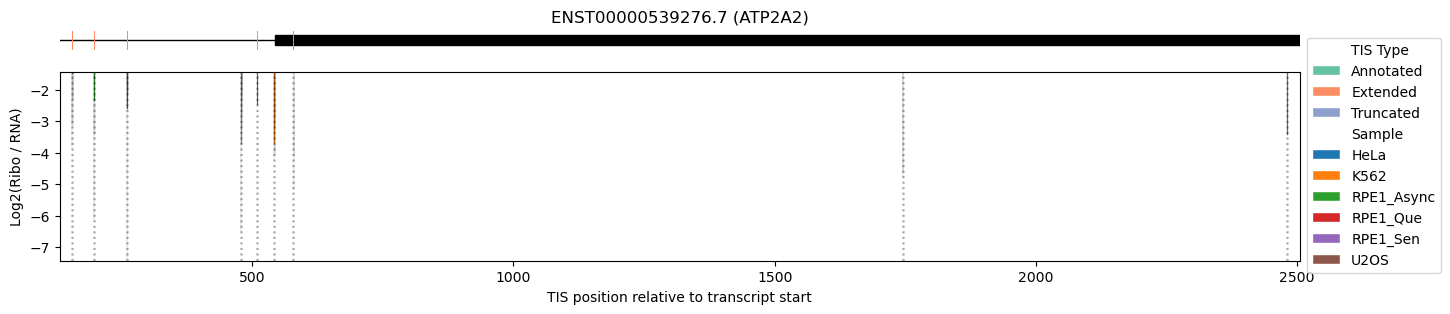

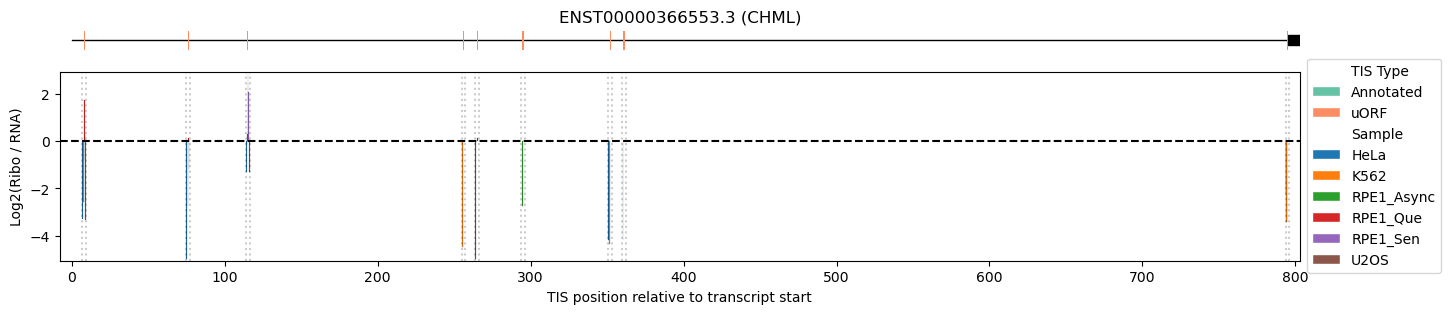

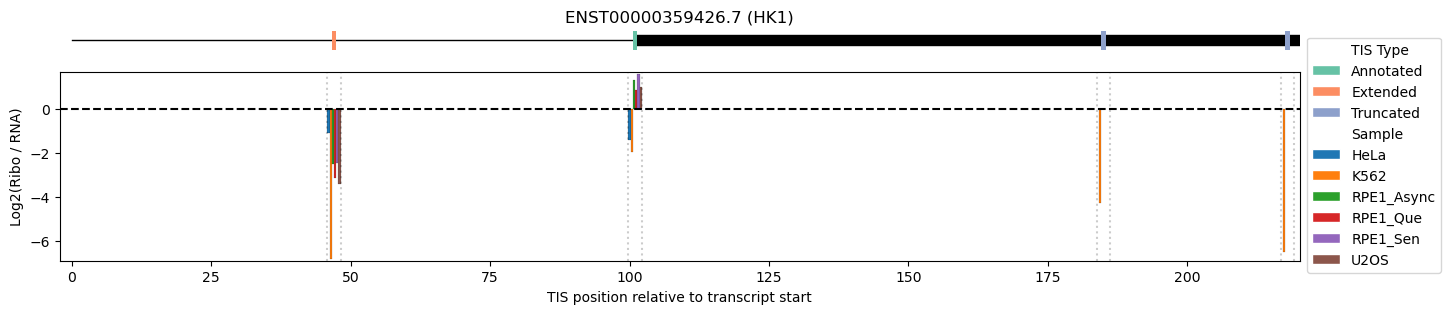

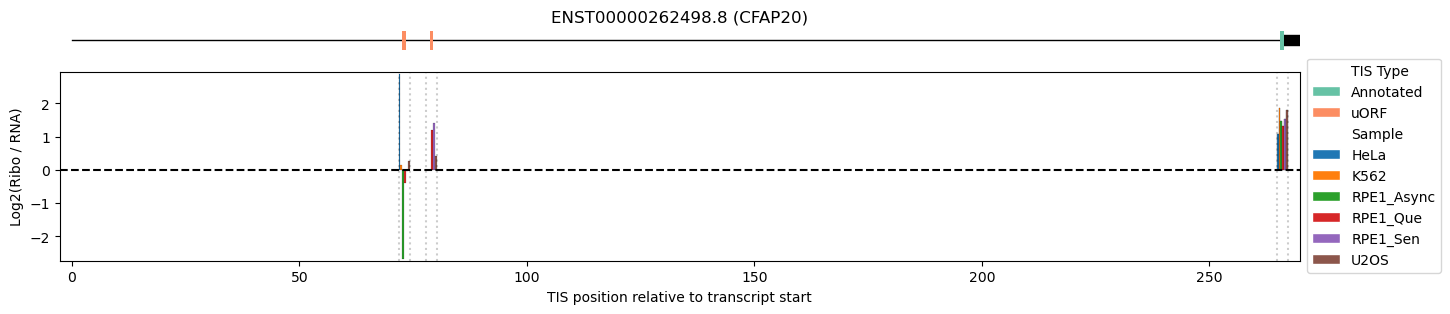

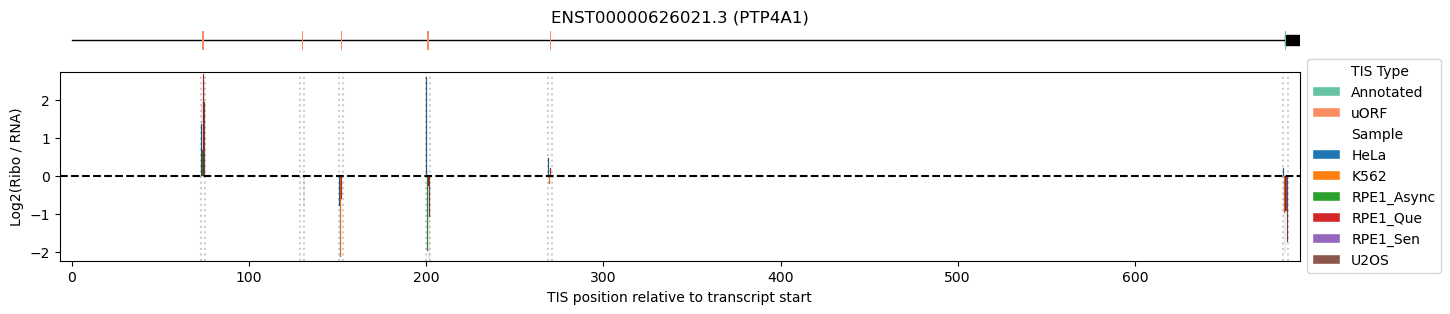

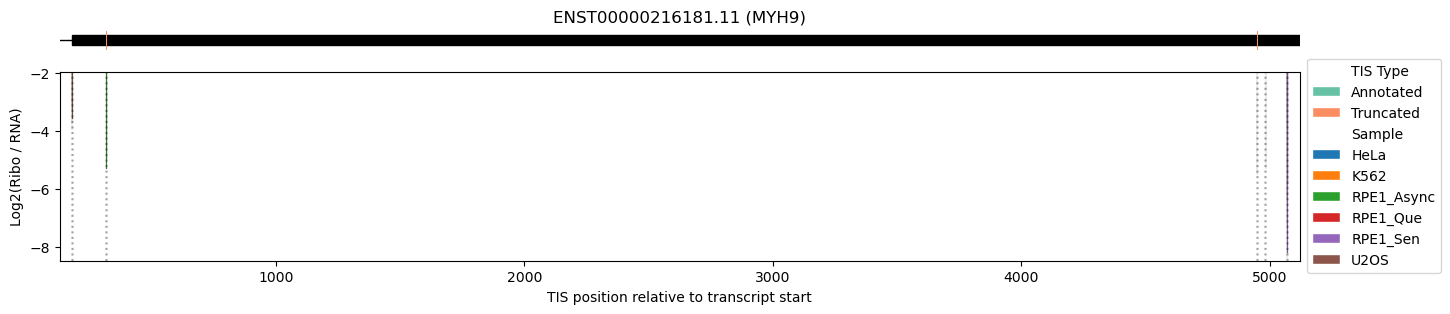

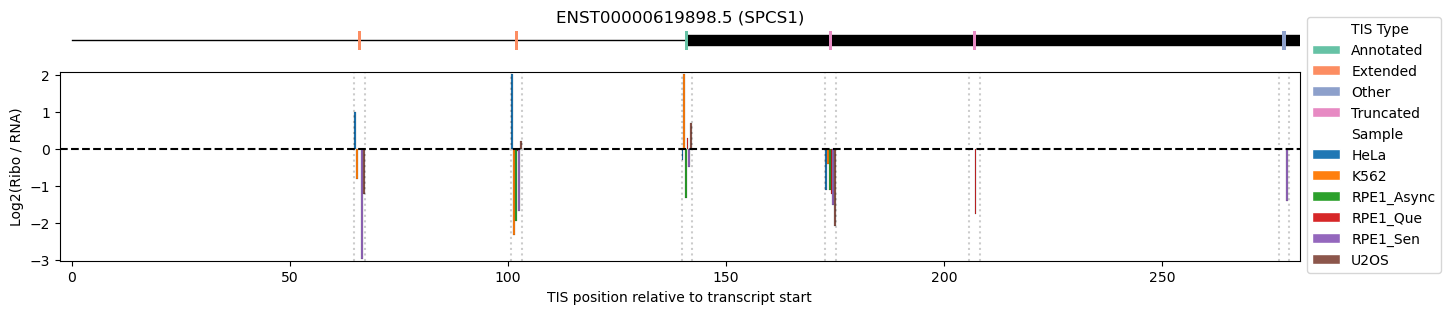

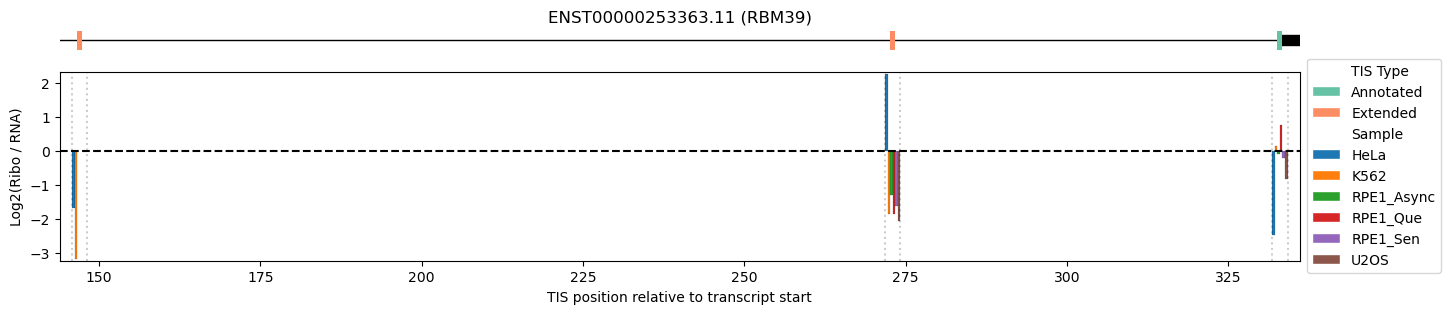

In [239]:
for t in func_annotated_outlier_df[func_annotated_outlier_df['MANE_Select']].head(10)['Tid'].unique().tolist():
    print(func_annotated_outlier_df[func_annotated_outlier_df['Tid'] == t]['Symbol'].iloc[0], 
          func_annotated_outlier_df[func_annotated_outlier_df['Tid'] == t].head(10)['Start'].tolist())
    plot_tis_over_cell_lines(t)

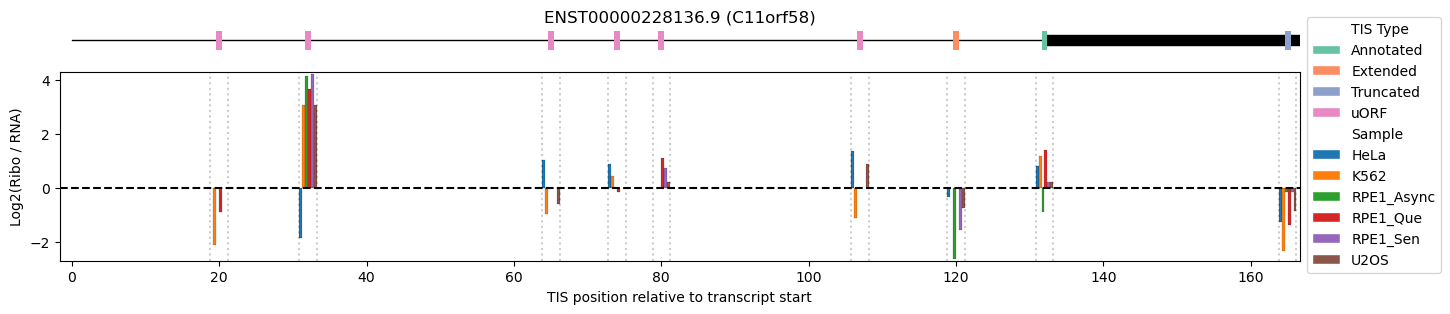

In [551]:
plot_tis_over_cell_lines('ENST00000228136.9')

PIGF [21.0]
SCAMP4 [16.0]
KRT10 [1806.0, 1593.0]
DDX5 [41.0]
NUDC [142.0]
NAA50 [226.0]
AP2M1 [121.0]
MPG [121.0]
CLPP [167.0]


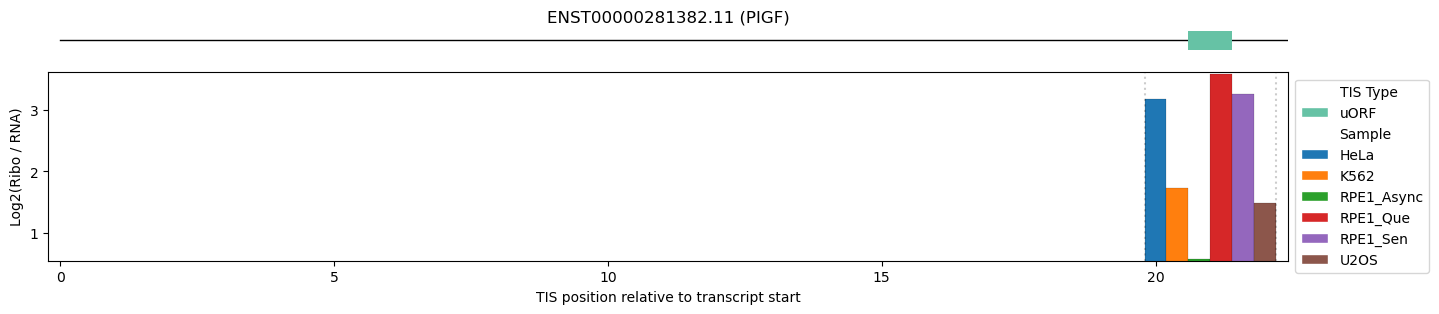

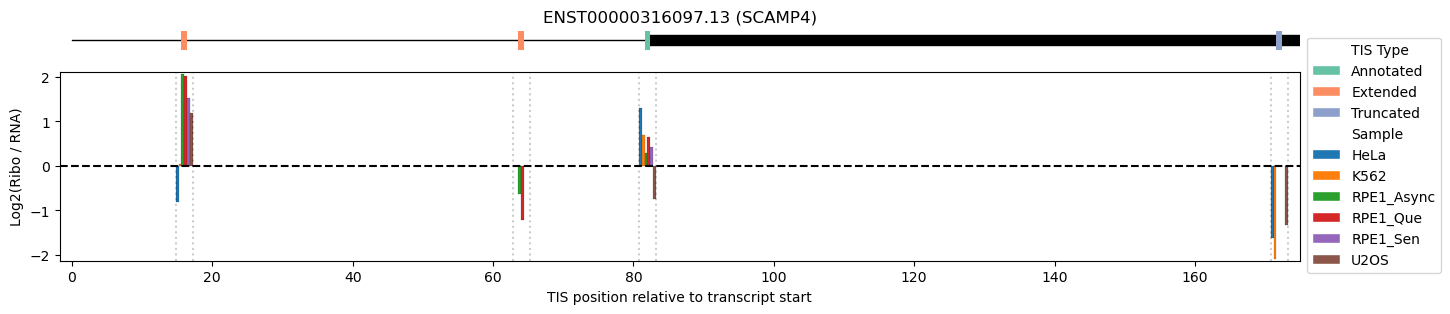

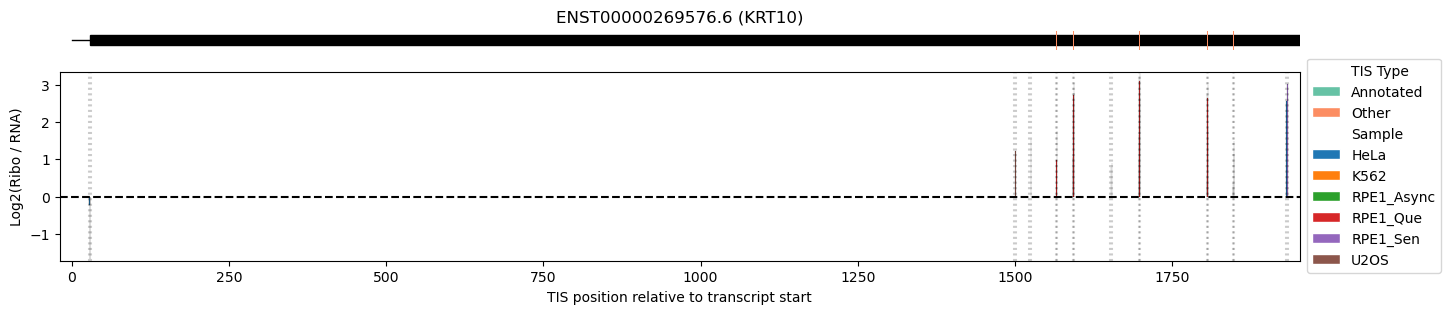

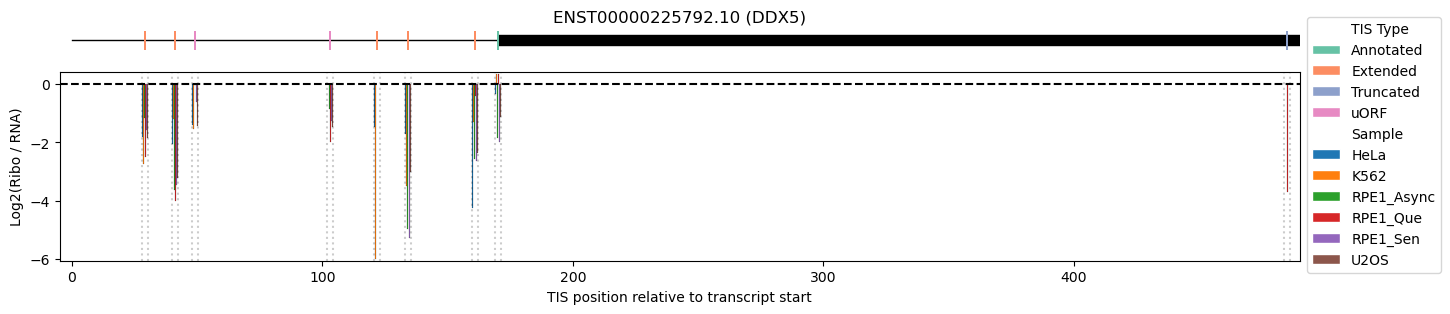

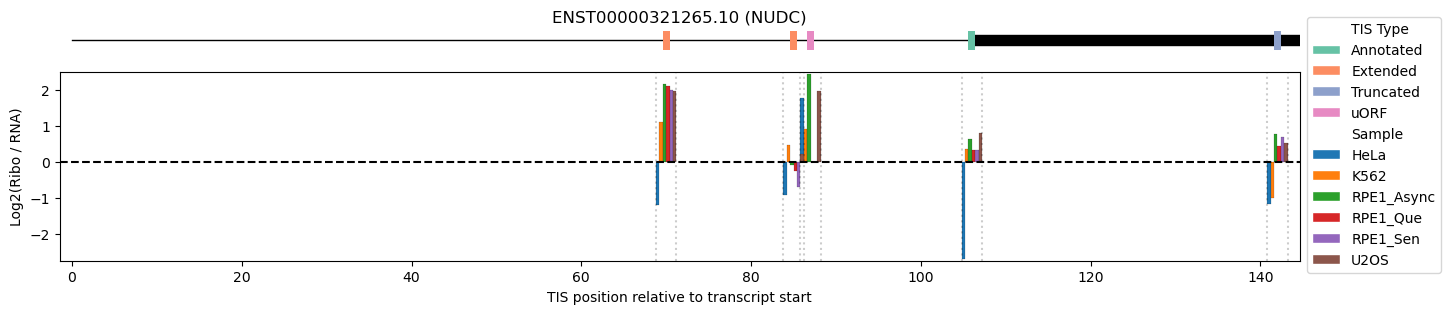

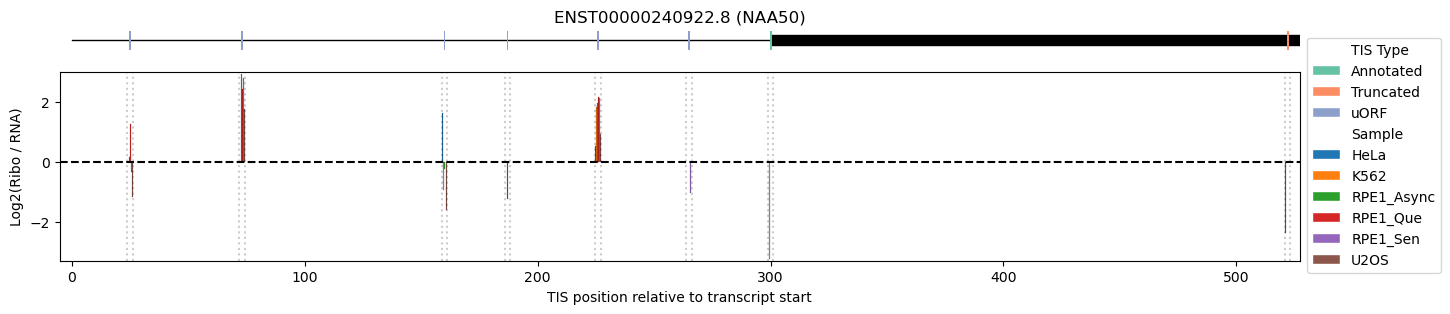

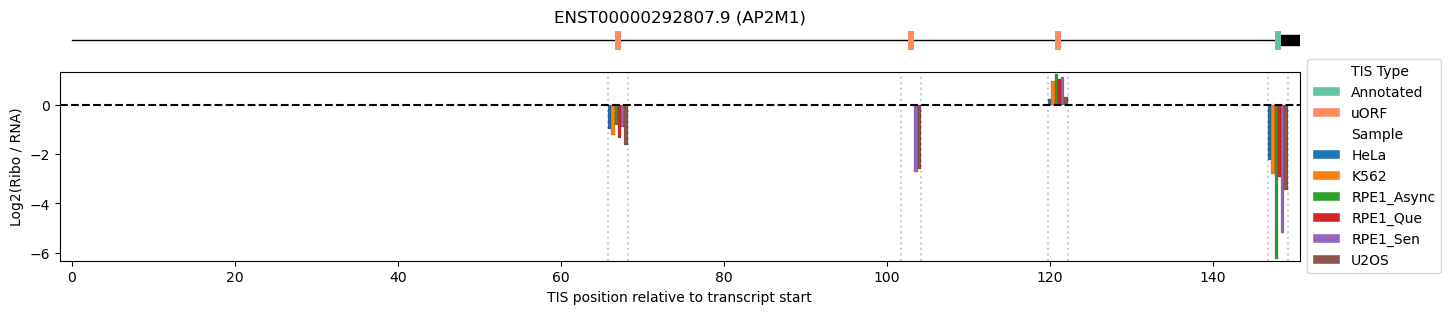

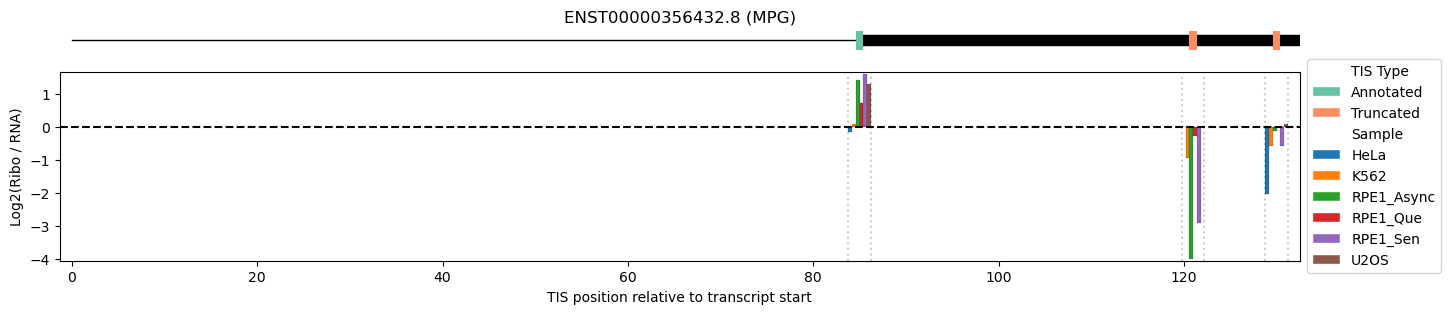

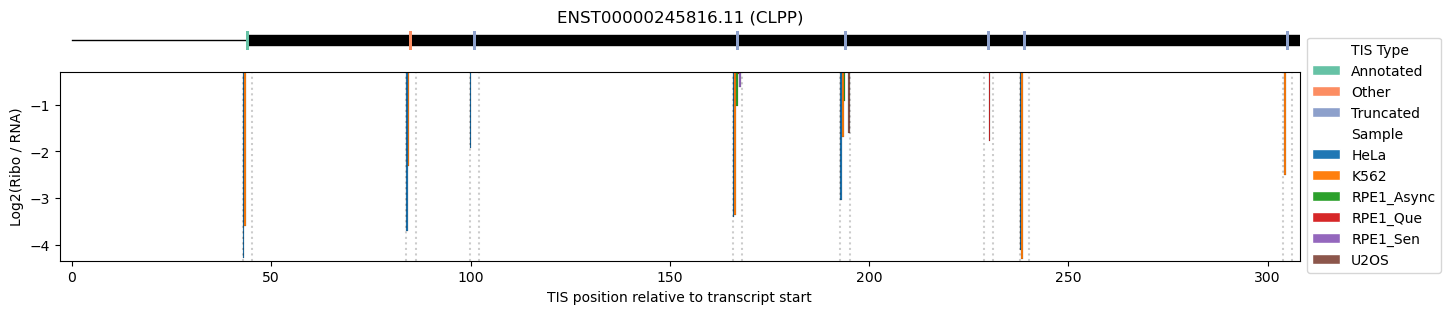

In [240]:
for t in func_annotated_continuum_df[func_annotated_continuum_df['MANE_Select']].head(10)['Tid'].unique().tolist():
    print(func_annotated_continuum_df[func_annotated_continuum_df['Tid'] == t]['Symbol'].iloc[0], 
          func_annotated_continuum_df[func_annotated_continuum_df['Tid'] == t].head(10)['Start'].tolist())
    plot_tis_over_cell_lines(t)

## Perform analysis again, pre-blocking the conditions to test

In [131]:
def summarize_tis_stats_across_samples(
    te_matrix=masked_te_matrix, 
    lfc_stack=lfc_block, qval_stack=qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=samples
):
    # reshape inputs depending on sample subset
    te_matrix = te_matrix.loc[:, sample_subset]
    lfc_stack = lfc_stack.loc[pd.IndexSlice[:, sample_subset], sample_subset]
    qval_stack = qval_stack.loc[pd.IndexSlice[:, sample_subset], sample_subset]
    tis_counts = tis_counts.loc[:, sample_subset]
    total_tis_counts = total_tis_counts.loc[sample_subset]

    # overall metrics on presence and variability across samples
    n_samples_per_tis = (~(te_matrix.isna())).sum(axis=1).rename('NSamples')
    variance_per_tis = te_matrix.var(axis=1).rename('LogTEVariance')

    # outlier detection by changes in spread
    variance_shifts, dropped_variances = calculate_variance_shifts(te_matrix, baseline_variance=variance_per_tis)
    min_delta_variance = variance_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaVariance')
    range_shifts, dropped_ranges = calculate_range_shifts(te_matrix)
    min_delta_range = range_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaRange')
    min_delta_variance_sample = variance_shifts.dropna(how='all').idxmin(axis=1).rename('CandidateOutlier').reindex(index=min_delta_variance.index)

    # Ribo/RNA values
    min_te_per_tis = te_matrix.min(axis=1).rename('MinLogRiboOverRNA')
    min_te_sample_per_tis = te_matrix.dropna(how='all').idxmin(axis=1).rename('MinLogTESample')
    max_te_per_tis = te_matrix.max(axis=1).rename('MaxLogRiboOverRNA')
    max_te_sample_per_tis = te_matrix.dropna(how='all').idxmax(axis=1).rename('MaxLogTESample')

    # metrics of fold changes and q-values for all pairwise comparisons
    lfc_reshaped = lfc_stack.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
    qval_reshaped = qval_stack.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
    min_lfc_per_tis = lfc_reshaped.min(axis=1).rename('MinLFC')
    min_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinLFCSamplePair')
    max_lfc_per_tis = lfc_reshaped.max(axis=1).rename('MaxLFCSamplePair')
    max_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmax(axis=1).apply(lambda x: '/'.join(x)).rename('MaxLFCSamplePair')
    min_diffq_per_tis = qval_reshaped.min(axis=1).rename('MinDiffQVal')
    min_diffq_pair_per_tis = qval_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinDiffQValSamplePair')
    median_diffq_per_tis = qval_reshaped.median(axis=1).rename('MedianDiffQVal')
    max_diffq_per_tis = qval_reshaped.max(axis=1).rename('MaxDiffQVal')
    min_median_diffq_magnitude_diff_per_tis = (np.log10(min_diffq_per_tis) - np.log10(median_diffq_per_tis)).abs().rename('QValMinMedianMagnitudeDiff')

    # direction of outlier change
    directions = []
    for tis, min_idx in tqdm(qval_reshaped.dropna(how='all').idxmin(axis=1).items()):
        directions.append(np.sign(lfc_reshaped.loc[tis, min_idx]))
    most_sig_direction_per_tis = pd.Series(directions, index=qval_reshaped.dropna(how='all').index).rename('MinDiffQValDirection')

    # data on raw counts
    max_riboseq_counts_per_tis = tis_counts.max(axis=1).rename('MaxRiboseqCounts')
    max_riboseq_rpm_per_tis = ((tis_counts / total_tis_counts) * 1e6).max(axis=1).rename('MaxRiboseqRPM')
    max_riboseq_sample_per_tis = ((tis_counts / total_tis_counts) * 1e6).idxmax(axis=1).rename('MaxRiboseqSample')
    min_riboseq_counts_per_tis = tis_counts.min(axis=1).rename('MinRiboseqCounts')
    min_riboseq_rpm_per_tis = ((tis_counts / total_tis_counts) * 1e6).min(axis=1).rename('MinRiboseqRPM')
    min_riboseq_sample_per_tis = ((tis_counts / total_tis_counts) * 1e6).idxmin(axis=1).rename('MinRiboseqSample')

    # merge metrics together
    tis_stats = pd.concat([
        n_samples_per_tis, variance_per_tis,
        max_riboseq_counts_per_tis, max_riboseq_rpm_per_tis, max_riboseq_sample_per_tis, min_riboseq_counts_per_tis, min_riboseq_rpm_per_tis, min_riboseq_sample_per_tis,
        max_te_per_tis, max_te_sample_per_tis, min_te_per_tis, min_te_sample_per_tis,
        max_lfc_per_tis, max_lfc_pair_per_tis, min_lfc_per_tis, min_lfc_pair_per_tis, most_sig_direction_per_tis,
        min_diffq_per_tis, min_diffq_pair_per_tis, median_diffq_per_tis, max_diffq_per_tis, min_median_diffq_magnitude_diff_per_tis,
        min_delta_variance, min_delta_range, min_delta_variance_sample
    ], axis=1)
    tis_summary = tis_metadata_df.merge(tis_stats, left_on='TIS', right_index=True)
    tis_summary = tis_summary.dropna(subset=['NSamples'])

    return tis_summary

In [ ]:
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5

In [149]:
cell_line_samples = ['HeLa', 'K562', 'RPE1_Async', 'U2OS']

cell_line_pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    cell_line_pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/pairwise_wald/{f}', index_col=0)

cell_line_tis_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/translation_efficiency_vst_matrix.csv', index_col=0)
cell_line_tis_matrix = cell_line_tis_matrix[tis_mask.reindex_like(cell_line_tis_matrix) & rna_mask.reindex_like(cell_line_tis_matrix)]

cell_line_lfc_block = extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=cell_line_pairwise_wald_tests, masked_tis_matrix=cell_line_tis_matrix)
cell_line_qval_block = extract_TIS_block(comparison_metric='padj', pairwise_dict=cell_line_pairwise_wald_tests, masked_tis_matrix=cell_line_tis_matrix)

100%|██████████| 6/6 [00:00<00:00,  6.11it/s]


In [150]:
cell_line_tis_summary = summarize_tis_stats_across_samples(
    te_matrix=cell_line_tis_matrix, 
    lfc_stack=cell_line_lfc_block, qval_stack=cell_line_qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=cell_line_samples
)

80362it [00:11, 6847.99it/s]


In [ ]:
cell_line_tis_summary.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/deseq2_tis_summary_statistics.csv', index=False)

In [151]:
rpe1_samples = ['RPE1_Async', 'RPE1_Que', 'RPE1_Sen']

rpe1_pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    rpe1_pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald/{f}', index_col=0)

rpe1_tis_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/translation_efficiency_vst_matrix.csv', index_col=0)
rpe1_tis_matrix = rpe1_tis_matrix[tis_mask.reindex_like(rpe1_tis_matrix) & rna_mask.reindex_like(rpe1_tis_matrix)]

rpe1_lfc_block = extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=rpe1_pairwise_wald_tests, masked_tis_matrix=rpe1_tis_matrix)
rpe1_qval_block = extract_TIS_block(comparison_metric='padj', pairwise_dict=rpe1_pairwise_wald_tests, masked_tis_matrix=rpe1_tis_matrix)

100%|██████████| 3/3 [00:00<00:00, 16.55it/s]


In [152]:
rpe1_tis_summary = summarize_tis_stats_across_samples(
    te_matrix=rpe1_tis_matrix, 
    lfc_stack=rpe1_lfc_block, qval_stack=rpe1_qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=rpe1_samples
)

52368it [00:07, 6798.29it/s]


In [154]:
rpe1_tis_summary.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/deseq2_tis_summary_statistics.csv', index=False)

# Check pairwise comparisons and outlier cell lines for functional enrichment

In [158]:
from gseapy import Msigdb
import gseapy as gp
msig = Msigdb()

In [159]:
msig.list_category(dbver='2026.1.Hs')

['c1.all',
 'c2.all',
 'c2.cgp',
 'c2.cp.biocarta',
 'c2.cp.kegg_legacy',
 'c2.cp.kegg_medicus',
 'c2.cp.pid',
 'c2.cp.reactome',
 'c2.cp',
 'c2.cp.wikipathways',
 'c3.all',
 'c3.mir.mir_legacy',
 'c3.mir.mirdb',
 'c3.mir',
 'c3.tft.gtrd',
 'c3.tft.tft_legacy',
 'c3.tft',
 'c4.3ca',
 'c4.all',
 'c4.cgn',
 'c4.cm',
 'c5.all',
 'c5.go.bp',
 'c5.go.cc',
 'c5.go.mf',
 'c5.go',
 'c5.hpo',
 'c6.all',
 'c7.all',
 'c7.immunesigdb',
 'c7.vax',
 'c8.all',
 'c9.all',
 'h.all',
 'msigdb']

In [ ]:
# gmt = msig.get_gmt(category='c2.cp', dbver='2026.1.Hs')
# curated_genesets = pd.DataFrame(pd.Series(gmt).explode().rename('Gene')).reset_index(names=['Geneset'])

In [160]:
# gmt = msig.get_gmt(category='c2.cp', dbver='2026.1.Hs')
curated_genesets = pd.concat({
    name: pd.DataFrame(pd.Series(msig.get_gmt(category=ds, dbver='2026.1.Hs')).explode().rename('Gene')).reset_index(names=['Geneset'])
    for ds, name in zip(['c2.cp.reactome', 'c5.go.bp', 'c5.go.cc', 'c5.go.mf'], ['Reactome', 'GOBP', 'GOCC', 'GOMF'])
}, axis=0).droplevel(1, axis=0).reset_index(names=['Collection'])

In [161]:
max_q = 0.01
min_effect = 1

pairwise_stats = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Async')]
significant_pairwise = pairwise_stats[
    (pairwise_stats['padj'] < max_q) & (
    pairwise_stats['log2FoldChange'].abs() > min_effect)
]
significant_pairwise = significant_pairwise.merge(
    tis_metadata, left_index=True, right_on=['TIS']
)

In [162]:
def initial_filter_for_gsea(deseq_results, min_lfc_filter=1, max_significance=0.01, direction='both', top_n=None, metadata_df=tis_metadata):
    if max_significance is None:
        significant_pairwise = deseq_results
    else:
        significant_pairwise = deseq_results[deseq_results['padj'] <= max_significance]

    if str.lower(direction) == 'both':
        significant_pairwise = significant_pairwise[
            significant_pairwise['log2FoldChange'].abs() >= min_lfc_filter
        ].sort_values('log2FoldChange', ascending=False)
    elif str.lower(direction) in ['high', 'up', 'positive']:
        significant_pairwise = significant_pairwise[
            significant_pairwise['log2FoldChange'] >= np.abs(min_lfc_filter)
        ].sort_values('log2FoldChange', ascending=False)
    elif str.lower(direction) in ['low', 'down', 'negative']:
        significant_pairwise = significant_pairwise[
            significant_pairwise['log2FoldChange'] <= -np.abs(min_lfc_filter)
        ].sort_values('log2FoldChange', ascending=True)

    if top_n is not None and str.lower(direction) == 'both':
        output_df = pd.concat([
            significant_pairwise.head(top_n),
            significant_pairwise.tail(top_n)
        ], axis=0, ignore_index=True).drop_duplicates()
    else:
        output_df = significant_pairwise.head(top_n)

    return output_df.merge(metadata_df, left_index=True, right_on='TIS', how='left')

def run_overrepresentation_analysis(filtered_deseq_table, genesets, alternative_only=True):
    if alternative_only:
        subset = filtered_deseq_table[filtered_deseq_table['RecatTISType'].isin(['Annotated'])]
    else:
        subset = filtered_deseq_table
    symbol_frequencies = subset.value_counts(['Symbol', 'RecatTISType']).reset_index()
    genelist = symbol_frequencies['Symbol'].unique().tolist()

    ora = gp.enrich(
        gene_list=genelist, 
        gene_sets=genesets, 
        outdir=None, 
        verbose=True)
    return ora.results.sort_values('Adjusted P-value')

In [163]:
from itertools import product
param_sets = [
    p for p in product(['both', 'up', 'down'], [['Annotated'], ['Extended'], ['Truncated'], ['uORF'], ['Extended', 'Truncated'], ['Extended', 'Truncated', 'uORF']])
]
pairwise_stats = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Async')]

conditions_to_overrepresentation_results = dict()

for params in tqdm(param_sets):
    direction, tis_classes = params
    tis_string = '|'.join(tis_classes)

    filtered_tis = initial_filter_for_gsea(pairwise_stats, direction=direction)
    filtered_tis = filtered_tis[filtered_tis['RecatTISType'].isin(tis_classes)]
    if len(filtered_tis) > 0:
        ora_results = run_overrepresentation_analysis(
            filtered_tis,
            curated_genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict(),
            alternative_only=False
        )
        conditions_to_overrepresentation_results[(direction, tis_string)] = ora_results

all_ora_enrichments_df = pd.concat(conditions_to_overrepresentation_results, axis=0).reset_index(names=['Direction', 'TISCategories', 'drop']).drop(['drop'], axis=1)

  0%|          | 0/18 [00:00<?, ?it/s]

2026-03-11 17:41:16,324 [INFO] Input dict object named with gs_ind_0
2026-03-11 17:41:16,325 [INFO] Run: gs_ind_0
2026-03-11 17:41:22,049 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-11 17:41:25,433 [INFO] Done.
  6%|▌         | 1/18 [00:10<03:03, 10.78s/it]2026-03-11 17:41:27,101 [INFO] Input dict object named with gs_ind_0
2026-03-11 17:41:27,101 [INFO] Run: gs_ind_0
2026-03-11 17:41:32,838 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-11 17:41:35,766 [INFO] Done.
 11%|█         | 2/18 [00:21<02:48, 10.52s/it]2026-03-11 17:41:37,418 [INFO] Input dict object named with gs_ind_0
2026-03-11 17:41:37,419 [INFO] Run: gs_ind_0
2026-03-11 17:41:43,120 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-11 17:41:46,340 [INFO] Done.
 17%|█▋        | 3/18 [00:31<02:38, 10.54s/it]2026-03-11 17:41:48,028 [INFO] Input dict object named with gs_ind_0
2026-03-11 17:41:48,029 [INFO] Run: gs_ind_0
2026-03-11 17:41:53,740 [INF

In [155]:
all_ora_enrichments_df[all_ora_enrichments_df['Adjusted P-value'] < 0.01]

,Direction,TISCategories,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,both,Annotated,gs_ind_0,GOBP_POSITIVE_REGULATION_OF_NERVOUS_SYSTEM_DEV...,15/278,1.028938e-07,0.000443,6.363380,102.384040,HDAC2;NAP1L1;MEGF8;NRP1;NUMBL;PLXNB2;FN1;GOLGA...
1,both,Annotated,gs_ind_0,GOBP_POSITIVE_REGULATION_OF_NEUROGENESIS,13/222,2.953020e-07,0.000635,6.912579,103.932469,HDAC2;NAP1L1;MEGF8;NRP1;NUMBL;PLXNB2;FN1;GOLGA...
2,both,Annotated,gs_ind_0,GOBP_INTRACELLULAR_TRANSPORT,35/1460,6.292047e-07,0.000729,2.852365,40.728373,TM9SF4;IPO9;SEC16A;TRAPPC1;TMEM41B;SNX1;NUP188...
3,both,Annotated,gs_ind_0,GOBP_ESTABLISHMENT_OF_LOCALIZATION_IN_CELL,42/1951,6.933977e-07,0.000729,2.596247,36.819095,TM9SF4;DYSF;IPO9;SEC16A;LPAR1;TRAPPC1;TMEM41B;...
4,both,Annotated,gs_ind_0,GOBP_POSITIVE_REGULATION_OF_AXONOGENESIS,8/77,8.472779e-07,0.000729,12.856973,179.756387,MEGF8;NRP1;PLXNB2;ZEB2;BRAF;SKIL;GOLGA4;FN1
...,...,...,...,...,...,...,...,...,...,...
73958,down,Extended|Truncated|uORF,gs_ind_0,GOBP_REGULATION_OF_INTRACELLULAR_TRANSPORT,12/285,5.906593e-04,0.009431,3.392645,25.221841,HSP90AA1;SMAD3;PTPN14;TMEM30A;PRKACA;SEC31A;NU...
73959,down,Extended|Truncated|uORF,gs_ind_0,GOBP_GLAND_DEVELOPMENT,16/457,5.948176e-04,0.009440,2.793214,20.745918,RELA;SMAD3;SLC7A5;RTN4;NRP1;HIPK2;ITGA2;DKK3;E...
73960,down,Extended|Truncated|uORF,gs_ind_0,GOMF_TRANSCRIPTION_COREGULATOR_ACTIVITY,18/550,6.072662e-04,0.009610,2.604667,19.291578,FHL2;RELA;ZMIZ2;PTPN14;NCOA3;TACC1;SPEN;KDM2A;...
73961,down,Extended|Truncated|uORF,gs_ind_0,GOBP_NEGATIVE_REGULATION_OF_MIRNA_METABOLIC_PR...,4/29,6.222282e-04,0.009819,12.869724,95.006925,NCOR1;REST;RELA;SMAD3


In [164]:
both_ora_q_matrix = all_ora_enrichments_df[
    all_ora_enrichments_df['Term'].str.contains('SENESCENCE') & 
    (all_ora_enrichments_df['Direction'] == 'both')
].pivot_table(index='Term', columns='TISCategories', values='Adjusted P-value')
both_ora_q_matrix

TISCategories,Annotated,Extended,Extended|Truncated,Extended|Truncated|uORF,Truncated,uORF
Term,,,,,,
GOBP_CELLULAR_SENESCENCE,0.527415,0.047238,0.032986,0.008913,0.492174,0.135695
GOBP_NEGATIVE_REGULATION_OF_CELLULAR_SENESCENCE,0.639663,0.274497,0.091782,0.141445,0.399906,0.624687
GOBP_ONCOGENE_INDUCED_CELL_SENESCENCE,0.080946,0.132064,0.007206,0.001993,0.026509,0.031756
GOBP_POSITIVE_REGULATION_OF_CELLULAR_SENESCENCE,0.867197,0.425744,0.444427,0.678427,0.755632,0.769560
GOBP_REGULATION_OF_CELLULAR_SENESCENCE,0.674462,0.131049,0.016601,0.042147,0.254486,0.463492
GOBP_REPLICATIVE_SENESCENCE,0.018461,0.386897,0.176923,0.069772,0.217853,0.023911
GOBP_STRESS_INDUCED_PREMATURE_SENESCENCE,NaN,0.178030,0.107268,0.058083,0.223260,0.009510
REACTOME_CELLULAR_SENESCENCE,0.807784,0.201924,0.000097,0.000026,0.000153,0.002351
REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SENESCENCE,0.797545,0.561737,0.003660,0.026842,0.001913,0.546808


In [165]:
up_ora_q_matrix = all_ora_enrichments_df[
    all_ora_enrichments_df['Term'].str.contains('SENESCENCE') & 
    (all_ora_enrichments_df['Direction'] == 'up')
].pivot_table(index='Term', columns='TISCategories', values='Adjusted P-value')
up_ora_q_matrix

TISCategories,Annotated,Extended,Extended|Truncated,Extended|Truncated|uORF,Truncated,uORF
Term,,,,,,
GOBP_CELLULAR_SENESCENCE,0.438497,0.034605,0.016325,0.124286,0.309994,0.496390
GOBP_NEGATIVE_REGULATION_OF_CELLULAR_SENESCENCE,0.570836,0.120039,0.044949,0.061182,0.394464,0.438027
GOBP_ONCOGENE_INDUCED_CELL_SENESCENCE,0.039128,0.334550,0.019372,0.045219,0.009018,0.111089
GOBP_POSITIVE_REGULATION_OF_CELLULAR_SENESCENCE,NaN,0.243913,0.195733,0.365500,0.575104,0.604754
GOBP_REGULATION_OF_CELLULAR_SENESCENCE,0.763295,0.067357,0.010647,0.042242,0.257831,0.340561
GOBP_REPLICATIVE_SENESCENCE,0.019542,0.219333,0.164135,0.137330,0.276683,0.121941
GOBP_STRESS_INDUCED_PREMATURE_SENESCENCE,NaN,0.102375,0.038114,0.087829,0.112200,0.029630
REACTOME_CELLULAR_SENESCENCE,0.589545,0.318866,0.009458,0.011573,0.006143,0.042357
REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SENESCENCE,0.736695,0.391357,0.011499,0.126029,0.009892,0.482335


In [166]:
down_ora_q_matrix = all_ora_enrichments_df[
    all_ora_enrichments_df['Term'].str.contains('SENESCENCE') & 
    (all_ora_enrichments_df['Direction'] == 'down')
].pivot_table(index='Term', columns='TISCategories', values='Adjusted P-value')
down_ora_q_matrix

TISCategories,Annotated,Extended,Extended|Truncated,Extended|Truncated|uORF,Truncated,uORF
Term,,,,,,
GOBP_CELLULAR_SENESCENCE,0.789224,0.457800,0.512790,0.077522,0.727855,0.110522
GOBP_NEGATIVE_REGULATION_OF_CELLULAR_SENESCENCE,0.753202,0.600458,0.560230,0.540361,0.660530,0.655920
GOBP_ONCOGENE_INDUCED_CELL_SENESCENCE,NaN,0.382207,0.153653,0.005306,0.385541,0.089717
GOBP_POSITIVE_REGULATION_OF_CELLULAR_SENESCENCE,0.701251,NaN,NaN,NaN,NaN,NaN
GOBP_REGULATION_OF_CELLULAR_SENESCENCE,0.607944,0.538292,0.512790,0.445249,0.628146,0.621624
GOBP_REPLICATIVE_SENESCENCE,0.681908,NaN,0.696282,0.575708,0.558806,0.287183
GOBP_STRESS_INDUCED_PREMATURE_SENESCENCE,NaN,NaN,NaN,0.634350,NaN,0.418176
REACTOME_CELLULAR_SENESCENCE,0.957427,0.341362,0.003438,0.000243,0.021466,0.034954
REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SENESCENCE,0.821648,0.870229,0.180638,0.130069,0.089552,0.567599


In [167]:
curated_genesets[curated_genesets['Geneset'].str.contains('SENESCENCE')].value_counts('Geneset')

Geneset
REACTOME_CELLULAR_SENESCENCE                                                                              197
REACTOME_OXIDATIVE_STRESS_INDUCED_SENESCENCE                                                              125
REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP                                                   111
GOBP_CELLULAR_SENESCENCE                                                                                  109
REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SENESCENCE                                                     79
GOBP_REGULATION_OF_CELLULAR_SENESCENCE                                                                     55
REACTOME_ONCOGENE_INDUCED_SENESCENCE                                                                       35
GOBP_NEGATIVE_REGULATION_OF_CELLULAR_SENESCENCE                                                            26
GOBP_POSITIVE_REGULATION_OF_CELLULAR_SENESCENCE                                                            19
RE

In [ ]:
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)

In [169]:
senescence_comparison_df = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Async')].merge(
    tis_metadata, left_index=True, right_on='TIS'
).assign(p_transform = lambda x: -np.log10(x['padj'])).merge(
    rpe1_tis_matrix.loc[:, ['RPE1_Sen', 'RPE1_Async']].add_prefix('LogTE_'), left_on='TIS', right_index=True
).merge(
    riboseq_counts.loc[:, ['RPE1_Sen', 'RPE1_Async']].add_prefix('RiboCounts_'), left_on='TIS', right_index=True
).merge(
    rna_counts.loc[:, ['RPE1_Sen', 'RPE1_Async']].add_prefix('RNACounts_'), left_on='TIS', right_index=True
)

senescence_comparison_df['Reactome_SENESCENCE'] = senescence_comparison_df['Symbol'].isin(
    curated_genesets[curated_genesets['Geneset'] == 'REACTOME_CELLULAR_SENESCENCE']['Gene'].tolist()
)

senescence_comparison_df['GOBP_SENESCENCE'] = senescence_comparison_df['Symbol'].isin(
    curated_genesets[curated_genesets['Geneset'] == 'GOBP_CELLULAR_SENESCENCE']['Gene'].tolist()
)

Text(0, 0.5, '-log10(Adjusted p-value)')

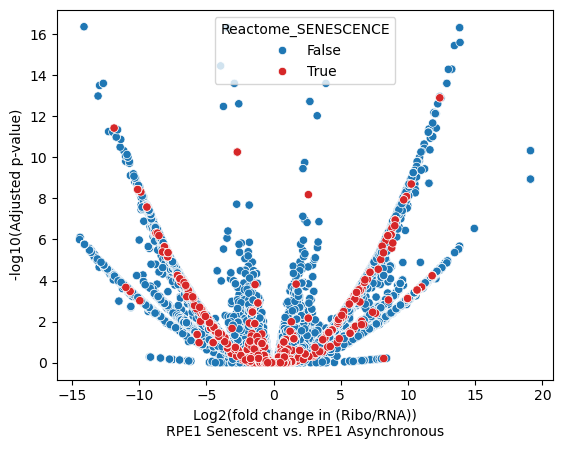

In [170]:
sns.scatterplot(
    senescence_comparison_df.sort_values('Reactome_SENESCENCE'),
    x='log2FoldChange', y='p_transform', hue='Reactome_SENESCENCE', palette={True: 'tab:red', False: 'tab:blue'}
)
plt.xlabel('Log2(fold change in (Ribo/RNA))\nRPE1 Senescent vs. RPE1 Asynchronous')
plt.ylabel('-log10(Adjusted p-value)')

Text(0, 0.5, '-log10(Adjusted p-value)')

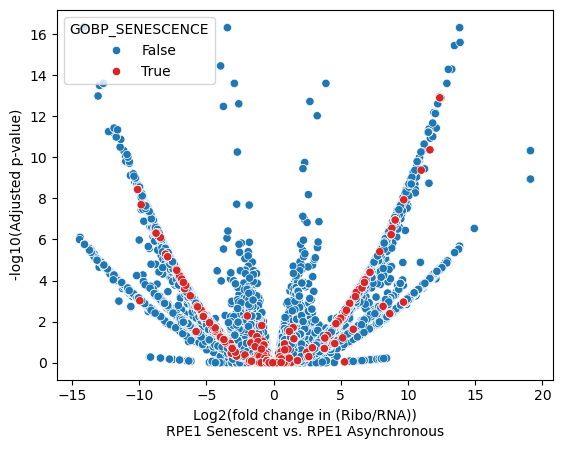

In [171]:
sns.scatterplot(
    senescence_comparison_df.sort_values('GOBP_SENESCENCE'),
    x='log2FoldChange', y='p_transform', hue='GOBP_SENESCENCE', palette={True: 'tab:red', False: 'tab:blue'}
)
plt.xlabel('Log2(fold change in (Ribo/RNA))\nRPE1 Senescent vs. RPE1 Asynchronous')
plt.ylabel('-log10(Adjusted p-value)')

In [172]:
senescence_comparison_df.sort_values('padj')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,TIS,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,p_transform,LogTE_RPE1_Sen,LogTE_RPE1_Async,RiboCounts_RPE1_Sen,RiboCounts_RPE1_Async,RNACounts_RPE1_Sen,RNACounts_RPE1_Async,Reactome_SENESCENCE,GOBP_SENESCENCE
56636,3524.739056,-14.095127,1.464872,-9.622090,6.450672e-22,4.367557e-17,ENST00000372079.1_37_chr1:45519043:-,ENST00000372079.1,PRDX1,ENSG00000117450.16,protein_coding,ATG,37.0,Annotated,False,97.0,MSSGNAKIGHPAPNFKATADEGISFRGLFIIDDKGILRQITVNDLP...,16.359761,NaN,5.291811,0,5944,6247,8444,False,False
261706,6046.615231,13.843871,1.460148,9.481145,2.515091e-21,4.851272e-17,ENST00000514924.5_271_chr4:41256976:+,ENST00000514924.5,UCHL1,ENSG00000154277.14,protein_coding,ATG,271.0,Annotated,False,58.0,MQLKPMEINPEMLNKVLSRLGVAGQWRFVDVLGLEEESLGSVPAPA...,16.314144,4.111098,NaN,7562,0,17223,17222,False,False
96918,262.393072,-3.431038,0.363297,-9.444163,3.582548e-21,4.851272e-17,ENST00000529887.6_128_chr11:117152447:+,ENST00000529887.6,PAFAH1B2,ENSG00000168092.15,protein_coding,ATG,128.0,Annotated,False,155.0,MSQGDSNPAAIPHAAEDIQGDDRWMSQHNRFVLDCKDKEPDVLFVG...,16.314144,-0.596291,2.785324,30,296,1748,2366,False,False
96923,262.393072,-3.431038,0.363297,-9.444163,3.582548e-21,4.851272e-17,ENST00000533206.1_44_chr11:117152447:+,ENST00000533206.1,PAFAH1B2,ENSG00000168092.15,protein_coding,ATG,44.0,Other,False,165.0,MSQGDSNPAAIPHAAEDIQGDDRWMSQHNRFVLDCKDKEPDVLFVG...,16.314144,-0.596291,2.785324,30,296,1748,2366,False,False
261711,6046.615231,13.843871,1.460148,9.481145,2.515091e-21,4.851272e-17,ENST00000512788.1_32_chr4:41256976:+,ENST00000512788.1,UCHL1,ENSG00000154277.14,protein_coding,ATG,32.0,Annotated,False,241.0,MQLKPMEINPEMLNKVLSRLGVAGQWRFVDVLGLEEESLGSVPAPA...,16.314144,4.111098,NaN,7562,0,17223,17222,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276701,28.897600,0.000295,2.061988,0.000143,9.998859e-01,9.999165e-01,ENST00000396301.7_129_chr12:13211510:+,ENST00000396301.7,EMP1,ENSG00000134531.11,protein_coding,ATG,129.0,Annotated,False,141.0,MLVLLAGIFVVHIATVIMLFVSTIANVWLVSNTVDASVGLWKNCTN...,0.000036,NaN,NaN,0,0,658,905,False,False
276702,28.897600,0.000295,2.061988,0.000143,9.998859e-01,9.999165e-01,ENST00000537612.1_0_chr12:13211510:+,ENST00000537612.1,EMP1,ENSG00000134531.11,protein_coding,ATG,0.0,Annotated,False,69.0,MLVLLAGIFVVHIATVIMLFVSTIANVWLVSNTVDASVGLWKNCTN...,0.000036,NaN,NaN,0,0,658,905,False,False
100590,62.242244,-0.000216,2.064897,-0.000105,9.999165e-01,9.999165e-01,ENST00000258530.8_15_chr12:105236159:-,ENST00000258530.8,APPL2,ENSG00000136044.13,protein_coding,CTG,15.0,Extended,True,713.0,LARRGRARGRRGHGVAAASPEPRAGECSRPPRLLPSVLPTQPSAEP...,0.000036,NaN,NaN,0,0,1859,2438,False,False
278400,62.242244,-0.000216,2.064897,-0.000105,9.999165e-01,9.999165e-01,ENST00000547439.5_44_chr12:105236159:-,ENST00000547439.5,APPL2,ENSG00000136044.13,protein_coding,CTG,44.0,Extended,False,284.0,LARRGRARGRRGHGVAAASPEPRAGECSRPPRLLPSVLPTQPSAEP...,0.000036,NaN,NaN,0,0,1859,2438,False,False


## RNAseq differential expression

In [173]:
pairwise_wald_rna_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald_rna'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    pairwise_wald_rna_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald_rna/{f}', index_col=0)

In [179]:
max_q = 0.01
min_effect = 1

pairwise_stats_rna = pairwise_wald_rna_tests[('RPE1_Sen', 'RPE1_Async')]
significant_pairwise_rna = pairwise_stats_rna[
    (pairwise_stats_rna['padj'] < max_q) & (
    pairwise_stats_rna['log2FoldChange'].abs() > min_effect)
]
significant_pairwise_rna = significant_pairwise_rna.merge(
    tis_metadata[['Gid', 'Symbol', 'RecatTISType']].drop_duplicates(subset=['Gid', 'Symbol']), left_index=True, right_on='Gid'
)
significant_pairwise_rna = significant_pairwise_rna[
    (significant_pairwise_rna['log2FoldChange'].abs() >= 1) & 
    (significant_pairwise_rna['padj'] <= 0.01)
]

both = significant_pairwise_rna.copy()
high = both[both['log2FoldChange'] > 0]
low = both[both['log2FoldChange'] < 0]

In [181]:
rna_sen_altered = run_overrepresentation_analysis(both, curated_genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict(), alternative_only=False)
rna_sen_up = run_overrepresentation_analysis(high, curated_genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict(), alternative_only=False)
rna_sen_down = run_overrepresentation_analysis(low, curated_genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict(), alternative_only=False)

2026-03-11 17:49:58,228 [INFO] Input dict object named with gs_ind_0
2026-03-11 17:49:58,229 [INFO] Run: gs_ind_0
2026-03-11 17:50:03,899 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-11 17:50:07,412 [INFO] Done.
2026-03-11 17:50:09,015 [INFO] Input dict object named with gs_ind_0
2026-03-11 17:50:09,016 [INFO] Run: gs_ind_0
2026-03-11 17:50:14,643 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-11 17:50:17,389 [INFO] Done.
2026-03-11 17:50:18,995 [INFO] Input dict object named with gs_ind_0
2026-03-11 17:50:18,995 [INFO] Run: gs_ind_0
2026-03-11 17:50:24,610 [INFO]   Background is not set! Use all 19656 genes in gs_ind_0.
2026-03-11 17:50:27,436 [INFO] Done.


In [182]:
rna_sen_altered.head(25)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
8302,gs_ind_0,REACTOME_CELL_CYCLE,233/688,9.366773e-73,8.995849e-69,5.447508,903.477656,NUP37;NUP188;VRK1;TOP2A;GINS2;H4C5;PTTG1;ZWINT...
8304,gs_ind_0,REACTOME_CELL_CYCLE_MITOTIC,198/552,2.262804e-66,1.086598e-62,5.859332,885.661480,NUP37;NUP188;VRK1;TOP2A;GINS2;H4C5;PTTG1;ZWINT...
577,gs_ind_0,GOBP_CELL_CYCLE_PROCESS,313/1395,2.809927e-51,8.995512e-48,3.119229,363.074180,NUP37;GPSM2;KIF20B;NUF2;NOP53;PDE4DIP;HAUS7;FM...
570,gs_ind_0,GOBP_CELL_CYCLE,352/1754,5.044748e-46,9.689951e-43,2.723661,284.079397,NUP37;GPSM2;KIF20B;NUF2;NOP53;PDE4DIP;HAUS7;ME...
8303,gs_ind_0,REACTOME_CELL_CYCLE_CHECKPOINTS,118/290,4.094471e-46,9.689951e-43,6.930729,724.325427,NUP37;H4C5;ZWINT;NUF2;CCNB1;RFC5;ORC6;H4C12;SP...
2069,gs_ind_0,GOBP_MITOTIC_CELL_CYCLE_PROCESS,212/811,5.076633e-45,8.125997e-42,3.688014,376.146757,DPF3;VRK1;KIF14;GPSM2;KIFC1;ZWINT;KIF20B;NUF2;...
931,gs_ind_0,GOBP_DNA_METABOLIC_PROCESS,247/1036,7.120546e-45,9.769390e-42,3.295468,334.995350,DPF3;TOP2A;DCLRE1C;ENDOG;FUS;GINS2;MMS22L;PTTG...
6109,gs_ind_0,GOCC_CHROMOSOMAL_REGION,142/419,3.799418e-44,4.561201e-41,5.221739,522.063732,NUP37;TOP2A;H4C5;ZWINT;NUF2;CDT1;THOC1;CCNB1;R...
696,gs_ind_0,GOBP_CHROMOSOME_ORGANIZATION,176/610,1.357026e-43,1.448098e-40,4.176054,412.200970,DPF3;TOP2A;KIF14;KIFC1;DCLRE1C;H4C5;PTTG1;ZWIN...
2066,gs_ind_0,GOBP_MITOTIC_CELL_CYCLE,231/959,1.132050e-42,1.087221e-39,3.319677,320.629517,DPF3;VRK1;KIF14;GPSM2;KIFC1;ZWINT;KIF20B;NUF2;...


In [183]:
rna_sen_up.head(25)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
5339,gs_ind_0,GOCC_VESICLE_MEMBRANE,91/1305,3.314006e-08,0.000181,1.980620,34.111282,EPHA4;ATP11B;CNIH3;VPS37D;SYNGR1;FMN2;TMEM165;...
5124,gs_ind_0,GOCC_ORGANELLE_SUBCOMPARTMENT,105/1600,5.991726e-08,0.000181,1.863898,30.997180,ARLN;PLA2G4C;CNIH3;ST3GAL1;CYB5A;FMN2;RDH10;CL...
4115,gs_ind_0,GOBP_RESPONSE_TO_ABIOTIC_STIMULUS,83/1172,7.302856e-08,0.000181,2.005215,32.950522,EPHA4;GSN;DCLRE1C;TP53INP1;NOP53;FMN2;TIMP1;BT...
2108,gs_ind_0,GOBP_NEGATIVE_REGULATION_OF_RESPONSE_TO_STIMULUS,118/1909,2.084330e-07,0.000379,1.752528,26.960269,HEG1;EPHA4;NOP53;CYLD;PTPRE;USP20;CASTOR1;SPP1...
4974,gs_ind_0,GOCC_GOLGI_APPARATUS,101/1566,2.550084e-07,0.000379,1.822025,27.661928,ATP11B;PDE4DIP;TGDS;TMEM192;ST3GAL1;TMEM165;NM...
1824,gs_ind_0,GOBP_NEGATIVE_REGULATION_OF_CELL_COMMUNICATION,102/1642,1.266840e-06,0.001387,1.745498,23.702093,HEG1;EPHA4;NOP53;CYLD;PTPRE;USP20;CASTOR1;ATXN...
5336,gs_ind_0,GOCC_VACUOLE,65/911,1.623239e-06,0.001387,1.999240,26.652045,ATP11B;DRAM1;SIAE;MFSD1;TP53INP1;ATP6AP2;ATP6V...
5029,gs_ind_0,GOCC_LYSOSOMAL_LUMEN,16/100,1.455123e-06,0.001387,4.913526,66.039859,HSPG2;GAA;TPP1;PSAP;MAN2B2;MANBA;ASAH1;FUCA1;T...
2969,gs_ind_0,GOBP_POSITIVE_REGULATION_OF_SIGNALING,114/1904,1.681308e-06,0.001387,1.683980,22.390098,EPHA4;MIB2;CYLD;CASTOR1;TRIM22;DAAM2;SPP1;EXTL...
4930,gs_ind_0,GOCC_ENDOPLASMIC_RETICULUM_LUMEN,31/326,4.370088e-06,0.003245,2.706596,33.401357,QSOX1;FKBP14;COL6A3;MFGE8;CERCAM;IGFBP7;SIL1;C...


In [184]:
rna_sen_down.head(25)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
6540,gs_ind_0,REACTOME_CELL_CYCLE,214/688,1.174675e-103,8.858227e-100,9.209948,2182.806216,NUP37;NUP188;VRK1;TOP2A;GINS2;H4C5;PTTG1;ZWINT...
6542,gs_ind_0,REACTOME_CELL_CYCLE_MITOTIC,186/552,2.639577e-96,9.952526e-93,10.110375,2225.066589,NUP37;NUP188;VRK1;TOP2A;GINS2;H4C5;PTTG1;ZWINT...
462,gs_ind_0,GOBP_CELL_CYCLE_PROCESS,258/1395,3.644336e-71,9.160646e-68,4.692830,761.131798,NUP37;FAM83D;VRK1;TOP2A;ASPM;KIF14;GPSM2;STK11...
455,gs_ind_0,GOBP_CELL_CYCLE,284/1754,1.652729e-65,3.115807e-62,4.043497,603.150737,NUP37;FAM83D;VRK1;TOP2A;ASPM;KIF14;GPSM2;STK11...
565,gs_ind_0,GOBP_CHROMOSOME_ORGANIZATION,158/610,4.889580e-63,7.374465e-60,6.720960,964.294838,TOP2A;KIF14;KIFC1;PTTG1;H4C5;ZWINT;NUF2;CDT1;C...
4800,gs_ind_0,GOCC_CHROMOSOMAL_REGION,131/419,1.022627e-62,1.285272e-59,8.579530,1224.624142,NUP37;TOP2A;H4C5;ZWINT;NUF2;CDT1;THOC1;CCNB1;R...
6541,gs_ind_0,REACTOME_CELL_CYCLE_CHECKPOINTS,110/290,1.686887e-62,1.817259e-59,11.345706,1613.783594,NUP37;H4C5;ZWINT;NUF2;CCNB1;RFC5;ORC6;H4C12;SP...
1647,gs_ind_0,GOBP_MITOTIC_CELL_CYCLE_PROCESS,181/811,1.354330e-61,1.276625e-58,5.605818,785.680024,VRK1;KIF14;GPSM2;KIFC1;ZWINT;KIF20B;NUF2;CDT1;...
727,gs_ind_0,GOBP_DNA_METABOLIC_PROCESS,206/1036,2.309669e-61,1.935246e-58,4.921679,687.167770,TOP2A;GINS2;ENDOG;FUS;MMS22L;PTTG1;SHMT1;CDT1;...
1644,gs_ind_0,GOBP_MITOTIC_CELL_CYCLE,197/959,5.800831e-61,4.374407e-58,5.095421,706.733295,VRK1;KIF14;GPSM2;KIFC1;ZWINT;KIF20B;NUF2;CDT1;...


In [185]:
rna_sen_altered[rna_sen_altered['Term'].str.contains('SENESCENCE')]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
8452,gs_ind_0,REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SE...,41/79,1.047269e-21,1.704741e-19,10.495184,507.002399,H2BC12;H2BC8;H2AC4;H2BC15;H4C5;POT1;H4C3;H2AC8...
8300,gs_ind_0,REACTOME_CELLULAR_SENESCENCE,61/197,2.100235e-17,1.921015e-15,4.410938,169.388381,H2BC12;H2BC8;H2AC4;MDM2;H2BC15;H4C5;TNIK;H3C3;...
9286,gs_ind_0,REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENO...,43/111,1.199826e-16,9.848826e-15,6.179360,226.530305,H2BC12;H2BC8;H2AC4;H2BC15;H4C5;H3C3;H4C3;RPS6K...
8969,gs_ind_0,REACTOME_OXIDATIVE_STRESS_INDUCED_SENESCENCE,42/125,8.974517e-14,6.069807e-12,4.945853,148.582342,H2BC12;H2BC8;H2AC4;MDM2;H2BC15;H4C5;TNIK;H3C3;...
9143,gs_ind_0,REACTOME_REGULATION_OF_MITF_M_DEPENDENT_GENES_...,4/6,1.033612e-03,1.673998e-02,17.211986,118.327170,MCM2;LIG1;MCM5;BRCA1
8565,gs_ind_0,REACTOME_FORMATION_OF_SENESCENCE_ASSOCIATED_HE...,5/17,1.788481e-02,1.603788e-01,4.207271,16.929232,H1-2;CDKN1A;H1-4;H1-5;LMNB1
548,gs_ind_0,GOBP_CELLULAR_SENESCENCE,17/109,2.765770e-02,2.210299e-01,1.812581,6.503270,SIRT6;SUV39H1;FBXO5;ULK3;CDKN1A;MNT;RBL1;ING2;...
5141,gs_ind_0,GOBP_REPLICATIVE_SENESCENCE,4/17,7.055533e-02,4.093359e-01,3.185434,8.445726,MME;SERPINE1;CHEK1;CDKN1A
8959,gs_ind_0,REACTOME_ONCOGENE_INDUCED_SENESCENCE,6/35,1.088481e-01,5.006101e-01,2.105995,4.670681,MDM2;CDKN2B;AGO3;TNRC6A;CDKN2C;ETS2
4302,gs_ind_0,GOBP_REGULATION_OF_CELLULAR_SENESCENCE,8/55,1.462498e-01,5.861324e-01,1.710482,3.288298,SUV39H1;SIRT6;FBXO5;YPEL3;RBL1;BCL2L12;ING2;BMAL1


In [186]:
rna_sen_up[rna_sen_up['Term'].str.contains('SENESCENCE')]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
4102,gs_ind_0,GOBP_REPLICATIVE_SENESCENCE,2/17,0.139549,0.594204,3.998581,7.874558,SERPINE1;CDKN1A
2343,gs_ind_0,GOBP_ONCOGENE_INDUCED_CELL_SENESCENCE,1/6,0.211464,0.632983,6.755946,10.496704,CDKN1A
4481,gs_ind_0,GOBP_STRESS_INDUCED_PREMATURE_SENESCENCE,1/8,0.271514,0.645617,4.953836,6.458524,CDKN1A
6544,gs_ind_0,REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SE...,4/79,0.367967,0.692672,1.476804,1.476454,H2BC12;POT1;CDKN1A;H2AC20
6936,gs_ind_0,REACTOME_ONCOGENE_INDUCED_SENESCENCE,2/35,0.396366,0.704948,1.848326,1.710474,MDM2;CDKN2B
7174,gs_ind_0,REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENO...,5/111,0.432574,0.723326,1.279165,1.071944,H2BC12;CDKN1A;H2AC20;IGFBP7;CDKN2B
6632,gs_ind_0,REACTOME_FORMATION_OF_SENESCENCE_ASSOCIATED_HE...,1/17,0.489992,0.745021,2.250671,1.605552,CDKN1A
2581,gs_ind_0,GOBP_POSITIVE_REGULATION_OF_CELLULAR_SENESCENCE,1/19,0.528852,0.763909,2.007142,1.278642,YPEL3
460,gs_ind_0,GOBP_CELLULAR_SENESCENCE,4/109,0.615434,0.809134,1.055175,0.512212,YPEL3;CDKN1A;CDKN2B;MNT
6427,gs_ind_0,REACTOME_CELLULAR_SENESCENCE,7/197,0.647081,0.829488,0.973375,0.423694,H2BC12;CDKN1A;MDM2;POT1;H2AC20;IGFBP7;CDKN2B


In [188]:
rna_sen_down[rna_sen_down['Term'].str.contains('SENESCENCE')]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
6667,gs_ind_0,REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SE...,37/79,1.292226e-25,1.188376e-23,15.345647,879.432335,H2BC8;H2AC4;H2BC15;H4C5;H4C3;H2AC8;H1-4;H4C2;M...
6538,gs_ind_0,REACTOME_CELLULAR_SENESCENCE,54/197,3.664467e-23,2.736015e-21,6.675800,344.877006,H2BC8;H2AC4;H2BC15;H4C5;TNIK;H3C3;H4C3;RPS6KA1...
7311,gs_ind_0,REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENO...,38/111,2.124595e-20,1.241982e-18,9.103253,412.360250,H2BC8;H2AC4;H2BC15;H4C5;H3C3;H4C3;RPS6KA1;H2AC...
7058,gs_ind_0,REACTOME_OXIDATIVE_STRESS_INDUCED_SENESCENCE,38/125,2.250581e-18,1.178585e-16,7.640940,310.492232,H2BC8;H2AC4;H2BC15;H4C5;TNIK;H3C3;H4C3;H2AC8;H...
7186,gs_ind_0,REACTOME_REGULATION_OF_MITF_M_DEPENDENT_GENES_...,4/6,1.340851e-04,1.838429e-03,30.429431,271.340318,MCM2;LIG1;MCM5;BRCA1
438,gs_ind_0,GOBP_CELLULAR_SENESCENCE,13/109,7.911037e-03,6.792047e-02,2.372455,11.481487,SIRT6;SUV39H1;FBXO5;ULK3;RBL1;ING2;BCL2L12;BRC...
6749,gs_ind_0,REACTOME_FORMATION_OF_SENESCENCE_ASSOCIATED_HE...,4/17,1.296319e-02,1.022546e-01,5.631739,24.473518,H1-5;H1-2;LMNB1;H1-4
3348,gs_ind_0,GOBP_REGULATION_OF_CELLULAR_SENESCENCE,7/55,3.301842e-02,2.087424e-01,2.614879,8.918539,SUV39H1;SIRT6;FBXO5;RBL1;BCL2L12;ING2;BMAL1
1842,gs_ind_0,GOBP_NEGATIVE_REGULATION_OF_CELLULAR_SENESCENCE,4/26,5.478176e-02,3.002247e-01,3.377403,9.809323,RBL1;SIRT6;FBXO5;BCL2L12
7051,gs_ind_0,REACTOME_ONCOGENE_INDUCED_SENESCENCE,4/35,1.302229e-01,5.489162e-01,2.411259,4.915370,AGO3;TNRC6A;CDKN2C;ETS2


Text(0.5, 1.0, 'RPE1_Sen vs. RPE1_Async')

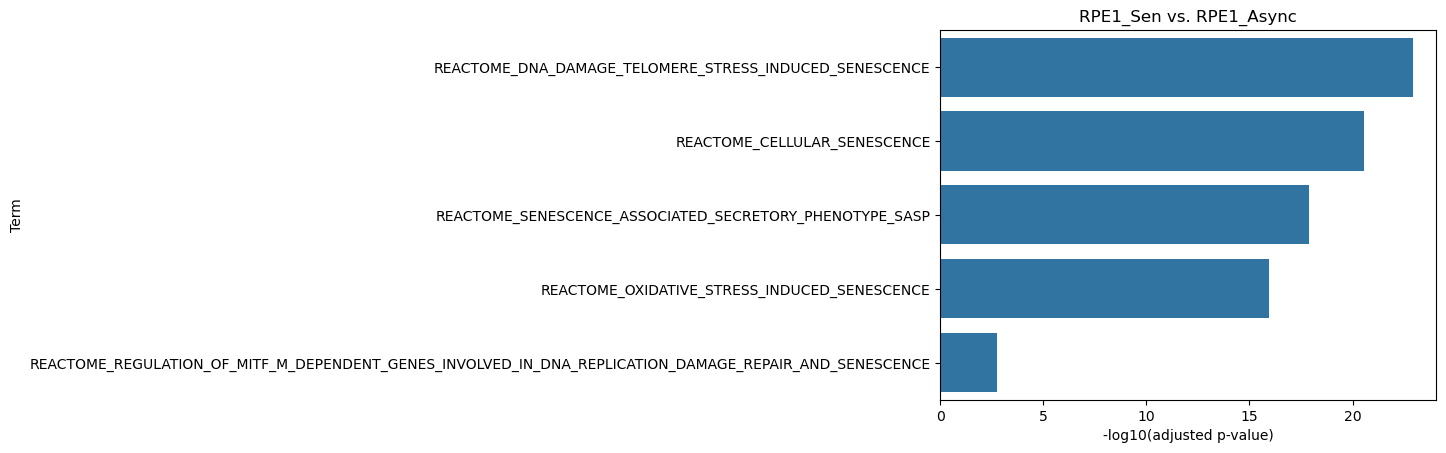

In [187]:
sns.barplot(
    rna_sen_down[rna_sen_down['Term'].str.contains('SENESCENCE')].head().assign(p_transform = lambda x: -np.log10(x['Adjusted P-value'])),
    x='p_transform', y='Term'
)
plt.xlabel('-log10(adjusted p-value)')
plt.title('RPE1_Sen vs. RPE1_Async')

In [189]:
significant_pairwise_rna[significant_pairwise_rna['Symbol'].isin(['JUN', 'UBC', 'CDKN1B'])]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gid,Symbol,RecatTISType


In [205]:
pairwise_stats_rna.merge(
    tis_metadata[['Gid', 'Symbol', 'RecatTISType']].drop_duplicates(subset=['Gid', 'Symbol']), left_index=True, right_on='Gid'
).query('Symbol.isin(["JUN", "UBC"])')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gid,Symbol,RecatTISType
16618,4119.669248,0.466501,0.191119,2.440886,0.014651,0.045048,ENSG00000150991.17,UBC,Annotated
57150,1111.772734,0.384077,0.297560,1.290754,0.196789,0.372691,ENSG00000177606.9,JUN,Extended


In [206]:
rna_counts.loc[['ENST00000371222.4_911_chr1:58783136:-', 
                'ENST00000339647.6_145_chr12:124913693:-'], :]

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
ENST00000371222.4_911_chr1:58783136:-,4,670,4329,484,4138,3494
ENST00000339647.6_145_chr12:124913693:-,1889,7896,11278,10793,11541,10562


In [207]:
(rna_counts / rna_counts.sum() * 1e6).loc[['ENST00000371222.4_911_chr1:58783136:-', 
                'ENST00000339647.6_145_chr12:124913693:-'], :]

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
ENST00000371222.4_911_chr1:58783136:-,0.040928,1.280287,7.140920,0.722615,10.234247,7.133044
ENST00000339647.6_145_chr12:124913693:-,19.328139,15.088279,18.603671,16.114020,28.543606,21.562454


# TIS usage per transcript as a vector

The concept here is to represent all TISs for a given transcript (or more complicatedly, a gene) as a vector of translation values

The length of this vector will vary per transcript; however, the distance between two samples for the same transcript (gene) can be calculated as a scalar value. Consider:
- Euclidean: sqrt(sum_i:N(delta_i^2))
- Manhattan: sum_i:N(|delta_i|)
- Chebyshev: max(|delta_i|)
- Cosine: 1 - (A@B)/(||A||*||B||)
